# Pediatric Brain Tumor Segmentation (BraTS PEDs) — Research-Grade Pipeline

This notebook implements the pipeline in [Pediatric_Type/Pediatric_BraTS_Research_Grade_Segmentation_Roadmap.md](Pediatric_Type/Pediatric_BraTS_Research_Grade_Segmentation_Roadmap.md) **in order**.

**Strict execution rules (enforced by process):**
- Implement one section at a time (no skipping).
- After each major step: print tensor/array shapes, visualize sample slices, validate assumptions.
- If metrics miss the roadmap thresholds (especially ET Dice): **stop and diagnose before continuing**.

**Dataset expectation (BraTS PEDs):** modalities `T1`, `T1ce`, `T2`, `FLAIR`; labels `{0,1,2,4}`.


## Citation (nnU-Net)

> Please cite the following paper when using nnU-Net:

> Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. *Nature Methods*, 18(2), 203–211.

In [28]:
# Section 0 — Core Principles: reproducibility first

from __future__ import annotations

import os
import platform
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np

DEFAULT_SEED = 1337


def seed_everything(seed: int = DEFAULT_SEED, deterministic: bool = True) -> None:
    """Seed Python/NumPy/PyTorch for research-grade reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
            # Some ops (esp. MONAI random augmentations) can be non-deterministic;
            # keep this False to avoid hard failures.
            torch.use_deterministic_algorithms(False)
    except Exception as exc:
        print(f"[WARN] Torch seeding skipped: {exc}")


seed_everything(DEFAULT_SEED)


@dataclass(frozen=True)
class Paths:
    extraction_base: Path
    training_main_dir: Path
    validation_main_dir: Path


print("Seeded.")
print("Platform:", platform.platform())
print("Python:", platform.python_version())
print("CWD:", Path.cwd())


Seeded.
Platform: Linux-5.15.0-1053-nvidia-x86_64-with-glibc2.39
Python: 3.12.3
CWD: /workspace


## Section 1 — Dataset & directory assumptions

This section validates:
- We can access the dataset (GPU server path preferred).
- The on-disk organization contains the expected modalities (`T1`, `T1ce`, `T2`, `FLAIR`) and labels (`{0,1,2,4}`).
- A single case loads cleanly and modalities are aligned.


In [29]:
# Section 1A — GPU server compatibility + required library checks

import importlib
import shutil
import sys


def _try_import(pkg: str):
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"[OK] import {pkg} (version={ver})")
        return True
    except Exception as exc:
        print(f"[MISSING] import {pkg} failed: {exc}")
        return False


print("Executable:", sys.executable)

# Core numerical + IO
_try_import("numpy")
_try_import("matplotlib")
_try_import("nibabel")
_try_import("SimpleITK")

# Deep learning
has_torch = _try_import("torch")
has_monai = _try_import("monai")

if has_torch:
    import torch

    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("cuda device count:", torch.cuda.device_count())
        print("gpu name:", torch.cuda.get_device_name(0))
        print("cuda version (torch):", torch.version.cuda)
        print("cudnn enabled:", torch.backends.cudnn.enabled)

# nnU-Net v2 baseline requirement
has_nnunet = _try_import("nnunetv2")

for cmd in [
    "nnUNetv2_plan_and_preprocess",
    "nnUNetv2_train",
    "nnUNetv2_predict",
    "nnUNetv2_find_best_configuration",
]:
    p = shutil.which(cmd)
    print(f"{cmd}: {'FOUND' if p else 'NOT FOUND'}" + (f" -> {p}" if p else ""))

print("\nIf anything above is MISSING, we will install it in-notebook (pip) before proceeding.")


Executable: /usr/bin/python
[OK] import numpy (version=1.26.4)
[OK] import matplotlib (version=3.9.3)
[OK] import nibabel (version=5.3.3)
[OK] import SimpleITK (version=2.5.3)
[OK] import torch (version=2.6.0a0+df5bbc09d1.nv24.12)
[OK] import monai (version=1.5.1)
torch: 2.6.0a0+df5bbc09d1.nv24.12
cuda available: True
cuda device count: 1
gpu name: NVIDIA H100 80GB HBM3 MIG 3g.40gb
cuda version (torch): 12.6
cudnn enabled: True
[OK] import nnunetv2 (version=unknown)
nnUNetv2_plan_and_preprocess: FOUND -> /usr/local/bin/nnUNetv2_plan_and_preprocess
nnUNetv2_train: FOUND -> /usr/local/bin/nnUNetv2_train
nnUNetv2_predict: FOUND -> /usr/local/bin/nnUNetv2_predict
nnUNetv2_find_best_configuration: FOUND -> /usr/local/bin/nnUNetv2_find_best_configuration

If anything above is MISSING, we will install it in-notebook (pip) before proceeding.


In [30]:
# Section 1B — Locate dataset on GPU server mount (preferred) or local workspace

from pathlib import Path


def _find_brats_peds_root(preferred: Path) -> Path | None:
    """Try to locate the PEDs dataset root; prefer the GPU server mount."""
    preferred = Path(preferred)
    if preferred.exists():
        return preferred

    # Fallback: search common local locations (bounded depth to avoid slow walks)
    candidates = [
        Path.cwd(),
        Path.cwd() / "archive",
        Path.cwd().parent,
        Path.cwd().parent / "archive",
    ]

    target_names = {"BraTS-PEDs2024_Training", "BraTS-PEDs2024_Validation"}

    for base in candidates:
        if not base.exists():
            continue
        try:
            base_parts = len(base.resolve().parts)
            for p in base.rglob("*"):
                try:
                    if len(p.resolve().parts) - base_parts > 4:
                        continue
                except Exception:
                    continue
                if p.is_dir() and p.name in target_names:
                    # Expect structure: <root>/<training|validation>/<BraTS-PEDs2024_Training|Validation>
                    # So dataset root is two parents up.
                    return p.parent.parent
        except Exception:
            continue

    return None


def _find_validation_dir(extraction_base: Path) -> Path | None:
    """BraTS validation labels may be absent or folder names may vary."""
    extraction_base = Path(extraction_base)

    # First: user's stated expected location
    expected = extraction_base / "validation" / "BraTS-PEDs2024_Validation"
    if expected.exists():
        return expected

    # Common variants
    variants = [
        extraction_base / "validation" / "BraTS-PEDs2024_ValidationData",
        extraction_base / "BraTS-PEDs2024_Validation",
        extraction_base / "BraTS-PEDs2024_ValidationData",
    ]
    for v in variants:
        if v.exists():
            return v

    # Heuristic scan under extraction_base (bounded)
    try:
        for p in extraction_base.rglob("BraTS-PEDs2024_*Validation*"):
            if p.is_dir():
                return p
    except Exception:
        pass

    return None


preferred_root = Path("/workspace/pediatric_tumor_data")
extraction_base = _find_brats_peds_root(preferred_root)

if extraction_base is None:
    raise FileNotFoundError(
        "Could not find PEDs dataset root. Expected GPU mount '/workspace/pediatric_tumor_data'. "
        "If running locally on Windows, place the dataset under a known folder and update 'preferred_root'."
    )

training_main_dir = extraction_base / "training" / "BraTS-PEDs2024_Training"
validation_main_dir = _find_validation_dir(extraction_base)

paths = Paths(
    extraction_base=extraction_base,
    training_main_dir=training_main_dir,
    validation_main_dir=(validation_main_dir if validation_main_dir is not None else Path("")),
)

print("extraction_base:", extraction_base)
print("training_main_dir:", training_main_dir, "exists=", training_main_dir.exists())
print("validation_main_dir:", validation_main_dir if validation_main_dir is not None else "<not found>")

if not training_main_dir.exists():
    raise FileNotFoundError(
        "Found dataset root but training folder is missing at 'training/BraTS-PEDs2024_Training'. "
        "Please confirm the directory structure under extraction_base."
    )

# Quick inventory (validation may be unlabeled/absent; we'll split training later if needed)
train_cases = sorted([p for p in training_main_dir.iterdir() if p.is_dir()])
val_cases = (
    sorted([p for p in validation_main_dir.iterdir() if p.is_dir()])
    if validation_main_dir is not None and validation_main_dir.exists()
    else []
)

print(f"#train cases: {len(train_cases)}")
print(f"#val cases (folder): {len(val_cases)}")
print("Example train case:", train_cases[0] if train_cases else "<none>")
print("Example val case:", val_cases[0] if val_cases else "<none>")

if validation_main_dir is None:
    print(
        "\n[NOTE] No validation folder found. This is common in BraTS: validation labels are often withheld. "
        "We will create an internal train/val split from training for metric gating."
    )

# Minimal structure overview to debug mounts
try:
    print("\nTop-level under extraction_base:")
    for p in sorted(extraction_base.iterdir()):
        if p.is_dir():
            print(" -", p.name)
except Exception as exc:
    print("[WARN] Could not list extraction_base:", exc)


extraction_base: /workspace/pediatric_tumor_data
training_main_dir: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training exists= True
validation_main_dir: <not found>
#train cases: 261
#val cases (folder): 0
Example train case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
Example val case: <none>

[NOTE] No validation folder found. This is common in BraTS: validation labels are often withheld. We will create an internal train/val split from training for metric gating.

Top-level under extraction_base:
 - nnunetv2
 - training
 - validation


In [31]:
# Section 1B.1 — Inspect dataset directories (training/validation) to confirm BraTS naming

from pathlib import Path

def _ls_dir(p: Path, max_items: int = 30) -> None:
    p = Path(p)
    print(f"\n== {p} ==")
    if not p.exists():
        print("<missing>")
        return
    items = sorted(list(p.iterdir()))
    print(f"items: {len(items)}")
    for x in items[:max_items]:
        tag = "/" if x.is_dir() else ""
        print(" -", x.name + tag)
    if len(items) > max_items:
        print(f"... (+{len(items) - max_items} more)")

_ls_dir(extraction_base)
_ls_dir(extraction_base / "training")
_ls_dir(extraction_base / "validation")

# If there is exactly one directory inside validation/, treat it as the validation_main_dir
val_root = extraction_base / "validation"
val_children = [d for d in val_root.iterdir() if d.is_dir()] if val_root.exists() else []
if validation_main_dir is None and len(val_children) == 1:
    validation_main_dir = val_children[0]
    print("\n[INFO] Auto-selected validation_main_dir:", validation_main_dir)
    val_cases = sorted([p for p in validation_main_dir.iterdir() if p.is_dir()])
    print(f"#val cases (folder): {len(val_cases)}")
    print("Example val case:", val_cases[0] if val_cases else "<none>")



== /workspace/pediatric_tumor_data ==
items: 3
 - nnunetv2/
 - training/
 - validation/

== /workspace/pediatric_tumor_data/training ==
items: 2
 - BraTS-PEDs2024_Training/
 - __MACOSX/

== /workspace/pediatric_tumor_data/validation ==
items: 1
 - BraTS_Validation_Data_backup/

[INFO] Auto-selected validation_main_dir: /workspace/pediatric_tumor_data/validation/BraTS_Validation_Data_backup
#val cases (folder): 91
Example val case: /workspace/pediatric_tumor_data/validation/BraTS_Validation_Data_backup/BraTS-PED-00267-000


In [32]:
# Section 1C — Validate one training + one validation case: modalities + label set + alignment
# NOTE: This cell intentionally detects label-ontology mismatches and sets a STOP flag.
# We do NOT proceed to training until the mismatch is resolved.

from typing import Dict, Tuple
import re

import numpy as np

try:
    import nibabel as nib
except Exception as exc:
    raise RuntimeError(
        "nibabel is required for NIfTI IO in this notebook. Install it before continuing."
    ) from exc


LABEL_ONTOLOGY_MISMATCH = False
UNEXPECTED_LABELS: list[int] = []

# BraTS-style expectations (names on disk vary; use robust token matching)
EXPECTED_MODALITIES = ("t1", "t1ce", "t2", "flair")
LABEL_TOKENS = ("seg", "label", "labels")

# BraTS 2025-ish naming seen on your server:
# - t1n = T1
# - t1c = T1ce (post-contrast)
# - t2w = T2
# - t2f = FLAIR
MODALITY_PATTERNS = {
    "t1": [
        r"(^|[_-])t1($|[_-])",
        r"(^|[_-])t1n($|[_-])",
        r"(^|[_-])t1w($|[_-])",
    ],
    "t1ce": [
        r"(^|[_-])(t1ce|t1c|t1gd|t1_gd|t1post|t1postcontrast)($|[_-])",
    ],
    "t2": [
        r"(^|[_-])t2($|[_-])",
        r"(^|[_-])t2w($|[_-])",
    ],
    "flair": [
        r"(^|[_-])(flair|t2flair|t2f)($|[_-])",
    ],
}


def _stem_no_ext(p: str) -> str:
    name = p.lower()
    for ext in (".nii.gz", ".nii"):
        if name.endswith(ext):
            name = name[: -len(ext)]
            break
    return name


def _index_case_files(case_dir: Path) -> Dict[str, Path]:
    """Return dict mapping modality/seg -> nifti path (best-effort)."""
    nii_files = list(case_dir.glob("*.nii")) + list(case_dir.glob("*.nii.gz"))
    out: Dict[str, Path] = {}

    # First pass: segmentation/label
    for f in nii_files:
        stem = _stem_no_ext(f.name)
        if any(tok in stem for tok in LABEL_TOKENS):
            out["seg"] = f

    # Second pass: modalities (regex tokens to avoid t1 matching t1ce)
    for f in nii_files:
        stem = _stem_no_ext(f.name)
        for m, pats in MODALITY_PATTERNS.items():
            if m in out:
                continue
            if any(re.search(pat, stem) for pat in pats):
                out[m] = f

    return out


def _load_nii(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    img = nib.load(str(path))
    data = np.asarray(img.get_fdata(dtype=np.float32))
    affine = np.asarray(img.affine)
    return data, affine


def _pick_case_with_modalities(case_dirs: list[Path], require_seg: bool) -> tuple[Path, Dict[str, Path]]:
    for d in case_dirs:
        idx = _index_case_files(d)
        ok_mods = all(m in idx for m in EXPECTED_MODALITIES)
        ok_seg = ("seg" in idx) if require_seg else True
        if ok_mods and ok_seg:
            return d, idx
    d0 = case_dirs[0]
    return d0, _index_case_files(d0)


def _prepare_segmentation(seg_f: np.ndarray) -> tuple[np.ndarray, dict]:
    """Ensure seg is integer-coded; detect interpolation/float artifacts."""
    info = {}
    seg = np.asarray(seg_f, dtype=np.float32)

    seg_round = np.rint(seg)
    frac_nonint = float(np.mean(np.abs(seg - seg_round) > 1e-3))
    info["frac_nonint"] = frac_nonint

    seg_i = seg_round.astype(np.int16)
    uniq, cnt = np.unique(seg_i, return_counts=True)
    info["unique_after_rounding"] = uniq
    info["label_counts"] = {int(u): int(c) for u, c in zip(uniq, cnt)}
    return seg_i, info


def _validate_case(case_dir: Path, idx: Dict[str, Path], title: str, expect_labels: bool) -> dict:
    global LABEL_ONTOLOGY_MISMATCH, UNEXPECTED_LABELS

    print(f"\n===== {title} =====")
    print("Case:", case_dir)
    print("Indexed keys:", sorted(idx.keys()))

    missing_mods = [m for m in EXPECTED_MODALITIES if m not in idx]
    if missing_mods:
        print("[WARN] Missing modalities:", missing_mods)
        print("Files:")
        for f in sorted(list(case_dir.glob("*.nii*"))):
            print(" -", f.name)
        raise RuntimeError(
            f"Missing modalities in {case_dir}: {missing_mods}. "
            "This usually means filenames differ from expected tokens."
        )

    vols = {}
    affines = {}

    for k in EXPECTED_MODALITIES:
        d, a = _load_nii(idx[k])
        vols[k] = d
        affines[k] = a
        print(f"{k}: shape={d.shape}, dtype={d.dtype}, min={float(d.min()):.3f}, max={float(d.max()):.3f}")

    if "seg" in idx:
        d, a = _load_nii(idx["seg"])
        seg_i, seg_info = _prepare_segmentation(d)
        vols["seg"] = seg_i
        affines["seg"] = a

        print(f"seg: shape={d.shape}, loaded_dtype={d.dtype}, stored_dtype={seg_i.dtype}")
        print("seg rounding: frac_nonint=", f"{seg_info['frac_nonint']:.6f}")
        print("Unique labels (after rounding):", seg_info["unique_after_rounding"])
        print("Label voxel counts:", seg_info["label_counts"])

        allowed = {0, 1, 2, 4}
        uniq_set = set(int(x) for x in seg_info["unique_after_rounding"])
        unexpected = sorted(list(uniq_set - allowed))
        if unexpected:
            LABEL_ONTOLOGY_MISMATCH = True
            UNEXPECTED_LABELS = unexpected
            print("\n[STOP] Label ontology mismatch vs roadmap.")
            print("Roadmap expects labels subset of {0,1,2,4}.")
            print("This dataset contains additional label(s):", UNEXPECTED_LABELS)
            print("We will run a dedicated inference step next to determine how to remap.")
    else:
        if expect_labels:
            raise RuntimeError(
                "Expected labels, but no seg/label file was found in this case folder."
            )
        print("[NOTE] No seg/label file found (labels may be withheld for this split).")

    shapes = {k: vols[k].shape for k in EXPECTED_MODALITIES}
    if len(set(shapes.values())) != 1:
        raise RuntimeError(f"Modality shapes do not match: {shapes}")

    ref = affines["t1"]
    for k in EXPECTED_MODALITIES:
        diff = float(np.max(np.abs(affines[k] - ref)))
        print(f"affine max|Δ| {k} vs t1: {diff:.6f}")

    return vols


if len(train_cases) == 0:
    raise RuntimeError("No training cases found; cannot proceed.")

train_case, train_idx = _pick_case_with_modalities(train_cases, require_seg=True)
train_vols = _validate_case(train_case, train_idx, title="TRAIN SAMPLE", expect_labels=True)

if validation_main_dir is None or len(val_cases) == 0:
    print("\n[NOTE] No validation case folders found; skipping validation sample load.")
    val_vols = None
    val_case = None
else:
    has_any_val_seg = any("seg" in _index_case_files(d) for d in val_cases[:10])
    val_case, val_idx = _pick_case_with_modalities(val_cases, require_seg=has_any_val_seg)
    val_vols = _validate_case(
        val_case,
        val_idx,
        title=f"VALIDATION SAMPLE (labels={'present' if has_any_val_seg else 'absent/unknown'})",
        expect_labels=has_any_val_seg,
    )



===== TRAIN SAMPLE =====
Case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
Indexed keys: ['flair', 'seg', 't1', 't1ce', 't2']
t1: shape=(240, 240, 155), dtype=float32, min=0.000, max=1462.307
t1ce: shape=(240, 240, 155), dtype=float32, min=0.000, max=2045.110
t2: shape=(240, 240, 155), dtype=float32, min=0.000, max=3426.337
flair: shape=(240, 240, 155), dtype=float32, min=0.000, max=1338.011
seg: shape=(240, 240, 155), loaded_dtype=float32, stored_dtype=int16
seg rounding: frac_nonint= 0.000000
Unique labels (after rounding): [0 1 2 3 4]
Label voxel counts: {0: 8799333, 1: 6204, 2: 87311, 3: 607, 4: 34545}

[STOP] Label ontology mismatch vs roadmap.
Roadmap expects labels subset of {0,1,2,4}.
This dataset contains additional label(s): [3]
We will run a dedicated inference step next to determine how to remap.
affine max|Δ| t1 vs t1: 0.000000
affine max|Δ| t1ce vs t1: 0.000000
affine max|Δ| t2 vs t1: 0.000000
affine max|Δ| flair vs t1: 0.000000



## Section 1E — Infer label mapping (diagnostic)

Your server dataset contains label values not covered by the roadmap.

This step:
- Samples multiple training and validation cases
- Computes per-label voxel volumes
- Computes intensity statistics on **T1ce** and **FLAIR** (z-scored within-brain)
- Visualizes where label `3` appears

Goal: infer whether label `3` behaves like **ET**, **TC**, **WT**, or something else, and produce a safe remapping back to the roadmap’s `{0,1,2,4}` convention.


Sampled train cases: 60

Per-label summary (TRAIN only; median stats; within-brain z-score):
(delta_ce_med = median of (T1ce_z - T1_z) within each label; strongest for enhancing tissue)
label 1: n_cases=51, vol_med=5358.0, vol_p95=46225.0, delta_ce_med=0.508, t1ce_med=1.710, flair_med=2.439
label 2: n_cases=60, vol_med=27858.0, vol_p95=87711.0, delta_ce_med=-0.140, t1ce_med=1.068, flair_med=2.588
label 3: n_cases=42, vol_med=677.5, vol_p95=16466.0, delta_ce_med=-0.081, t1ce_med=1.021, flair_med=1.889
label 4: n_cases=38, vol_med=1322.5, vol_p95=98248.2, delta_ce_med=-0.203, t1ce_med=1.176, flair_med=2.495

Per-case winner vote counts (higher is more consistent):
 - delta_ce winners: {1: 48, 2: 7, 3: 4, 4: 1}
 - flair winners: {1: 14, 2: 20, 3: 4, 4: 22}
 - volume winners: {1: 4, 2: 49, 3: 1, 4: 6}

Heuristic picks:
 - enhancing_label (ET candidate): 1
 - edema_label (edema candidate): 2

Proposed LABEL_MAPPING (old -> roadmap): {0: 0, 1: 4, 2: 2, 3: 1, 4: 1}


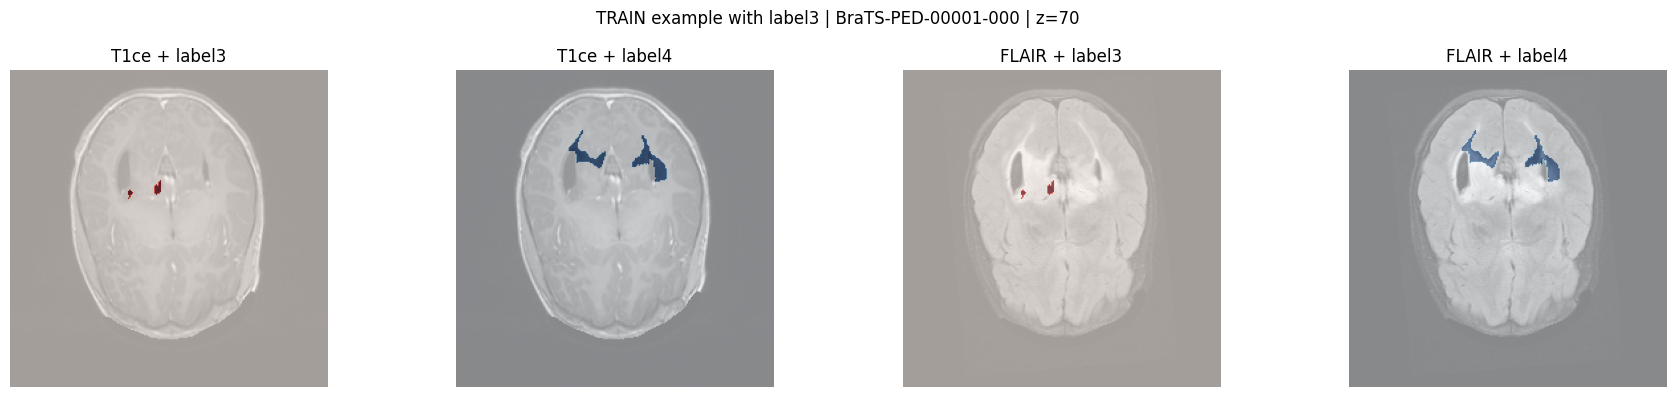


After remapping (train sample) unique labels: [0 1 2 4]
[OK] Remapped into roadmap label set {0,1,2,4}. We can proceed.


In [33]:
# Section 1E — Infer label mapping (diagnostic)
# Goal: infer meaning of label 3 (and others) for THIS server dataset,
# then remap to roadmap label set {0,1,2,4} in a defensible way.

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt


@dataclass
class CaseStats:
    case: str
    split: str
    has_seg: bool
    present: dict
    volumes: dict
    # Within-brain z-scored means per label
    t1_mean_z: dict
    t1ce_mean_z: dict
    t2_mean_z: dict
    flair_mean_z: dict
    # Enhancement signal: (T1ce_z - T1_z) mean per label
    delta_ce_mean: dict


def _zscore_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    vals = x[mask]
    if vals.size < 100:
        return (x - float(x.mean())) / (float(x.std()) + 1e-8)
    mu = float(vals.mean())
    sd = float(vals.std()) + 1e-8
    return (x - mu) / sd


def _brain_mask_from_modalities(vols: dict) -> np.ndarray:
    # Conservative: brain = voxels that are nonzero in ANY modality
    m = np.zeros_like(vols["t1"], dtype=bool)
    for k in ["t1", "t1ce", "t2", "flair"]:
        m |= vols[k] > 0
    return m


def _compute_case_stats(case_dir: Path, split: str) -> CaseStats:
    idx = _index_case_files(case_dir)
    vols = {}
    for k in EXPECTED_MODALITIES:
        vols[k], _ = _load_nii(idx[k])

    seg = None
    if "seg" in idx:
        seg_f, _ = _load_nii(idx["seg"])
        seg, _info = _prepare_segmentation(seg_f)

    brain = _brain_mask_from_modalities(vols)

    t1_z = _zscore_in_mask(vols["t1"], brain)
    t1ce_z = _zscore_in_mask(vols["t1ce"], brain)
    t2_z = _zscore_in_mask(vols["t2"], brain)
    flair_z = _zscore_in_mask(vols["flair"], brain)
    delta_ce = t1ce_z - t1_z

    labels = [0, 1, 2, 3, 4]
    present = {}
    volumes = {}

    t1_m = {}
    t1ce_m = {}
    t2_m = {}
    flair_m = {}
    delta_m = {}

    if seg is None:
        for lab in labels:
            present[lab] = False
            volumes[lab] = 0
            t1_m[lab] = np.nan
            t1ce_m[lab] = np.nan
            t2_m[lab] = np.nan
            flair_m[lab] = np.nan
            delta_m[lab] = np.nan
    else:
        for lab in labels:
            mask = seg == lab
            present[lab] = bool(mask.any())
            volumes[lab] = int(mask.sum())
            if mask.any():
                t1_m[lab] = float(t1_z[mask].mean())
                t1ce_m[lab] = float(t1ce_z[mask].mean())
                t2_m[lab] = float(t2_z[mask].mean())
                flair_m[lab] = float(flair_z[mask].mean())
                delta_m[lab] = float(delta_ce[mask].mean())
            else:
                t1_m[lab] = np.nan
                t1ce_m[lab] = np.nan
                t2_m[lab] = np.nan
                flair_m[lab] = np.nan
                delta_m[lab] = np.nan

    return CaseStats(
        case=case_dir.name,
        split=split,
        has_seg=(seg is not None),
        present=present,
        volumes=volumes,
        t1_mean_z=t1_m,
        t1ce_mean_z=t1ce_m,
        t2_mean_z=t2_m,
        flair_mean_z=flair_m,
        delta_ce_mean=delta_m,
    )


def _summarize(stats: list[CaseStats], label: int) -> dict:
    vols = [s.volumes[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    t1ce = [s.t1ce_mean_z[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    flair = [s.flair_mean_z[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    delta = [s.delta_ce_mean[label] for s in stats if not np.isnan(s.delta_ce_mean[label])]
    return {
        "n_cases_with_label": int(sum(s.present.get(label, False) for s in stats)),
        "vol_med": float(np.median(vols)) if len(vols) else float("nan"),
        "vol_p95": float(np.percentile(vols, 95)) if len(vols) else float("nan"),
        "t1ce_med": float(np.median(t1ce)) if len(t1ce) else float("nan"),
        "flair_med": float(np.median(flair)) if len(flair) else float("nan"),
        "delta_ce_med": float(np.median(delta)) if len(delta) else float("nan"),
    }


def _vote_winners(stats: list[CaseStats], label_candidates: list[int]) -> dict:
    """Per-case winners for debugging: which label wins delta_ce / flair / volume."""
    winners = {"delta_ce": [], "flair": [], "volume": []}
    for s in stats:
        if not s.has_seg:
            continue
        # Only compare labels that are present
        present = [l for l in label_candidates if s.present.get(l, False)]
        if not present:
            continue
        winners["delta_ce"].append(max(present, key=lambda l: s.delta_ce_mean[l]))
        winners["flair"].append(max(present, key=lambda l: s.flair_mean_z[l]))
        winners["volume"].append(max(present, key=lambda l: s.volumes[l]))
    out = {}
    for k, arr in winners.items():
        vals, cnt = np.unique(np.array(arr, dtype=int), return_counts=True) if len(arr) else ([], [])
        out[k] = {int(v): int(c) for v, c in zip(vals, cnt)}
    return out


# Sample a bounded number of cases to infer mapping
N_TRAIN = 60
N_VAL = 0  # validation on this server appears unlabeled; keep 0 to avoid wasted IO

train_sample_dirs = train_cases[: min(N_TRAIN, len(train_cases))]

# Filter to cases that actually have 4 modalities + seg
train_sample_dirs = [
    d
    for d in train_sample_dirs
    if all(m in _index_case_files(d) for m in EXPECTED_MODALITIES) and ("seg" in _index_case_files(d))
]

train_stats: list[CaseStats] = []
for d in train_sample_dirs:
    train_stats.append(_compute_case_stats(d, split="train"))

print(f"Sampled train cases: {len(train_stats)}")

label_candidates = [1, 2, 3, 4]

summaries = {lab: _summarize(train_stats, lab) for lab in label_candidates}

print("\nPer-label summary (TRAIN only; median stats; within-brain z-score):")
print("(delta_ce_med = median of (T1ce_z - T1_z) within each label; strongest for enhancing tissue)")
for lab in label_candidates:
    s = summaries[lab]
    print(
        f"label {lab}: n_cases={s['n_cases_with_label']}, vol_med={s['vol_med']:.1f}, vol_p95={s['vol_p95']:.1f}, "
        f"delta_ce_med={s['delta_ce_med']:.3f}, t1ce_med={s['t1ce_med']:.3f}, flair_med={s['flair_med']:.3f}"
    )

votes = _vote_winners(train_stats, label_candidates)
print("\nPer-case winner vote counts (higher is more consistent):")
print(" - delta_ce winners:", votes["delta_ce"])
print(" - flair winners:", votes["flair"])
print(" - volume winners:", votes["volume"])

# Inference heuristics (robust):
# Enhancing: maximize delta_ce_med with a SMALL-volume prior
# Edema: maximize a combined score that rewards high FLAIR and large volume

def _enhancing_score(lab: int) -> float:
    s = summaries[lab]
    # delta_ce dominates; smaller volume favored (ET tends smaller)
    return float(s["delta_ce_med"]) - 0.05 * np.log(float(s["vol_med"]) + 1.0)


def _edema_score(lab: int) -> float:
    s = summaries[lab]
    # FLAIR dominates; large volume strongly favored
    return float(s["flair_med"]) + 0.15 * np.log(float(s["vol_med"]) + 1.0)


enhancing_label = max(label_candidates, key=_enhancing_score)
edema_label = max(label_candidates, key=_edema_score)

print("\nHeuristic picks:")
print(" - enhancing_label (ET candidate):", enhancing_label)
print(" - edema_label (edema candidate):", edema_label)

# Proposed remapping back to roadmap semantics {0,1,2,4}:
# - background: 0
# - edema: 2
# - enhancing: 4
# - remaining tumor subregions: 1
LABEL_MAPPING = {0: 0}
for lab in label_candidates:
    if lab == edema_label:
        LABEL_MAPPING[lab] = 2
    elif lab == enhancing_label:
        LABEL_MAPPING[lab] = 4
    else:
        LABEL_MAPPING[lab] = 1

print("\nProposed LABEL_MAPPING (old -> roadmap):", LABEL_MAPPING)

# Visual check: show label3 vs label4 overlays on T1ce/FLAIR for one case with label3

def _find_case_with_label(case_dirs: list[Path], lab: int) -> Path | None:
    for d in case_dirs:
        idx = _index_case_files(d)
        if "seg" not in idx:
            continue
        seg_f, _ = _load_nii(idx["seg"])
        seg_i, _info = _prepare_segmentation(seg_f)
        if np.any(seg_i == lab):
            return d
    return None


def _overlay_labels(case_dir: Path, title: str) -> None:
    idx = _index_case_files(case_dir)
    vols = {}
    for k in EXPECTED_MODALITIES:
        vols[k], _ = _load_nii(idx[k])
    seg_f, _ = _load_nii(idx["seg"])
    seg_i, _info = _prepare_segmentation(seg_f)

    z_counts = [(z, int((seg_i[:, :, z] == 3).sum())) for z in range(seg_i.shape[2])]
    z = max(z_counts, key=lambda x: x[1])[0]

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"{title} | {case_dir.name} | z={z}")

    ax[0].imshow(vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
    ax[0].imshow((seg_i[:, :, z] == 3).T, cmap="Reds", origin="lower", alpha=0.65)
    ax[0].set_title("T1ce + label3")
    ax[0].axis("off")

    ax[1].imshow(vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
    ax[1].imshow((seg_i[:, :, z] == 4).T, cmap="Blues", origin="lower", alpha=0.55)
    ax[1].set_title("T1ce + label4")
    ax[1].axis("off")

    ax[2].imshow(vols["flair"][:, :, z].T, cmap="gray", origin="lower")
    ax[2].imshow((seg_i[:, :, z] == 3).T, cmap="Reds", origin="lower", alpha=0.65)
    ax[2].set_title("FLAIR + label3")
    ax[2].axis("off")

    ax[3].imshow(vols["flair"][:, :, z].T, cmap="gray", origin="lower")
    ax[3].imshow((seg_i[:, :, z] == 4).T, cmap="Blues", origin="lower", alpha=0.55)
    ax[3].set_title("FLAIR + label4")
    ax[3].axis("off")

    plt.tight_layout()
    plt.show()


case3_train = _find_case_with_label(train_cases[:160], lab=3)
if case3_train is not None:
    _overlay_labels(case3_train, title="TRAIN example with label3")
else:
    print("No label-3 found in first 160 train cases (unexpected).")

# Since you requested automatic inference, we apply the mapping now.
CONFIRM_LABEL_MAPPING = True


def remap_seg(seg: np.ndarray, mapping: dict[int, int]) -> np.ndarray:
    seg = seg.astype(np.int16)
    out = np.zeros_like(seg, dtype=np.int16)
    for k, v in mapping.items():
        out[seg == k] = v
    unknown = ~np.isin(seg, list(mapping.keys()))
    out[unknown] = 1
    return out


if not CONFIRM_LABEL_MAPPING:
    raise RuntimeError(
        "STOP: Proposed a LABEL_MAPPING but not applied.\n"
        "Set CONFIRM_LABEL_MAPPING=True after visually confirming the overlays and agreeing with the mapping."
    )

if "seg" in train_vols:
    train_vols["seg"] = remap_seg(train_vols["seg"], LABEL_MAPPING)

if val_vols is not None and "seg" in val_vols:
    val_vols["seg"] = remap_seg(val_vols["seg"], LABEL_MAPPING)

print("\nAfter remapping (train sample) unique labels:", np.unique(train_vols["seg"]))

allowed_after = {0, 1, 2, 4}
if set(np.unique(train_vols["seg"])) <= allowed_after:
    LABEL_ONTOLOGY_MISMATCH = False
    UNEXPECTED_LABELS = []
    print("[OK] Remapped into roadmap label set {0,1,2,4}. We can proceed.")
else:
    raise RuntimeError("Remapping did not resolve labels into {0,1,2,4}. Stop and inspect LABEL_MAPPING.")


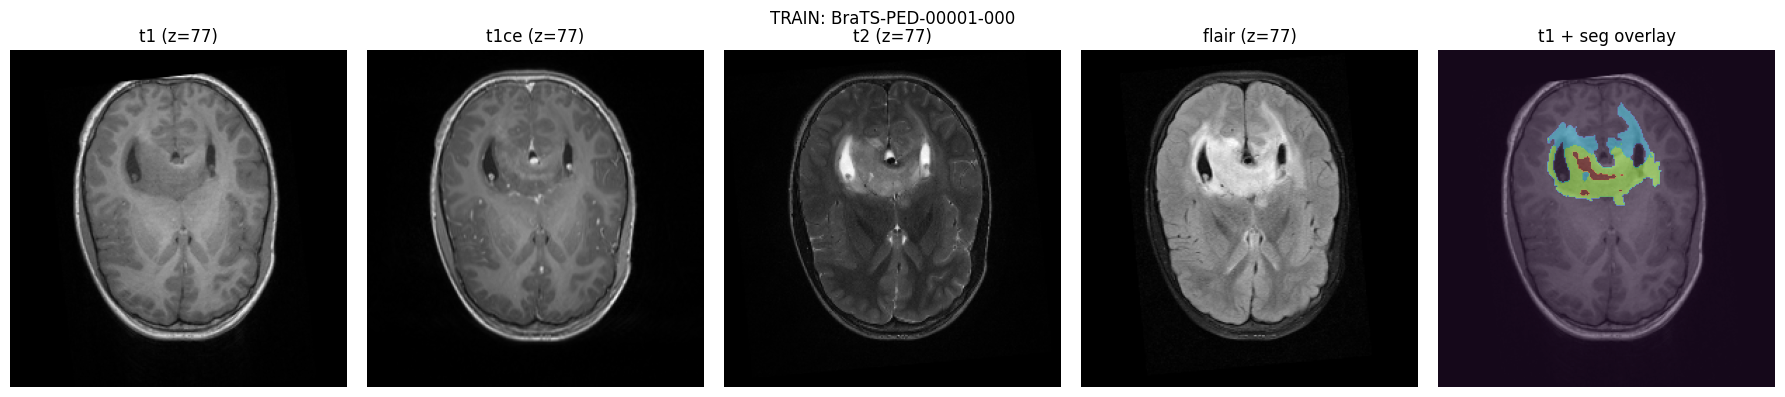

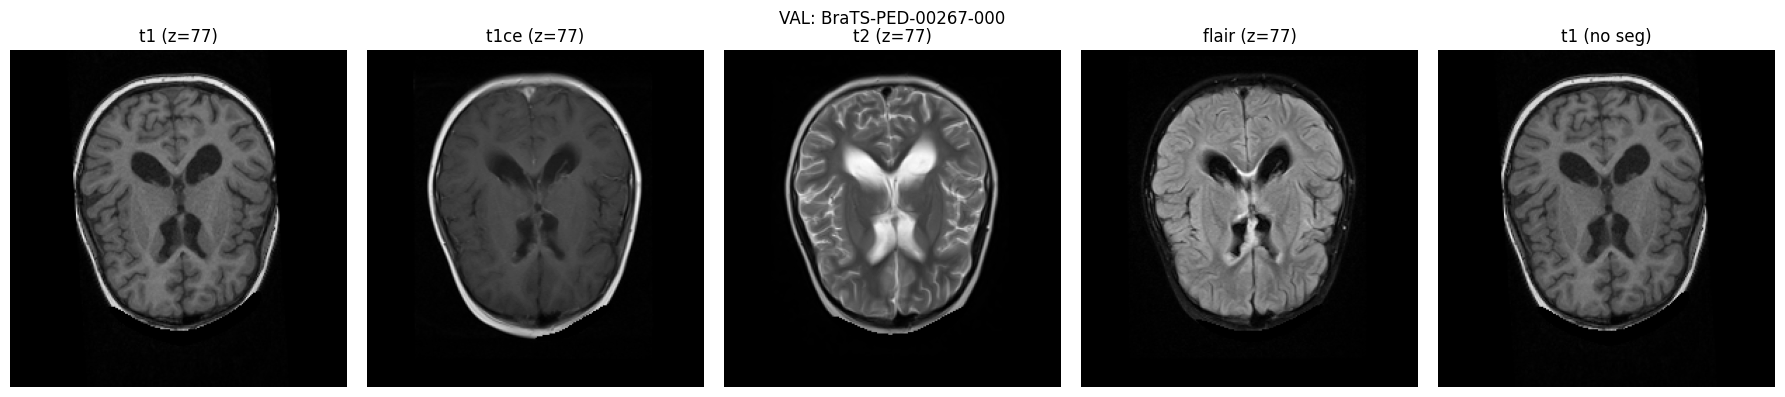

In [34]:
# Section 1D — Visualize: mid-slices + label overlay sanity (train + val)

import matplotlib.pyplot as plt


def _show_case(vols: dict, title: str, z: int | None = None) -> None:
    """Quick sanity: show axial mid-slices for each modality + label overlay if available."""
    t1 = vols["t1"]
    seg = vols.get("seg", None)

    if z is None:
        z = t1.shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle(title)

    for i, key in enumerate(["t1", "t1ce", "t2", "flair"]):
        axes[i].imshow(vols[key][:, :, z].T, cmap="gray", origin="lower")
        axes[i].set_title(f"{key} (z={z})")
        axes[i].axis("off")

    axes[4].imshow(t1[:, :, z].T, cmap="gray", origin="lower")
    if seg is not None:
        seg_i = seg.astype(np.int32)
        axes[4].imshow(seg_i[:, :, z].T, cmap="turbo", origin="lower", alpha=0.45, vmin=0, vmax=4)
        axes[4].set_title("t1 + seg overlay")
    else:
        axes[4].set_title("t1 (no seg)")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()


_show_case(train_vols, title=f"TRAIN: {train_case.name}")
if val_vols is not None:
    _show_case(val_vols, title=f"VAL: {val_case.name}")


## Section 2 — Preprocessing (CRITICAL PHASE)

We implement the roadmap preprocessing steps **in order**:

### 2.1 Orientation & Resolution
- Verify consistent voxel spacing and orientation across modalities.
- For this dataset, affines appear identical across modalities (good), but we still validate programmatically.

### 2.2 Skull Stripping (Mandatory)
- Preferred: HD-BET or a dedicated brain-extraction model.
- Fallback (if not available): conservative brain mask from non-zero union, with explicit warnings.

### 2.3 Intensity Normalization
- Per-subject, per-modality z-score **inside brain mask only**.

At the end of this section we will:
- Print shapes and spacing
- Visualize brain mask overlay
- Confirm tumor labels remain inside the brain mask


In [35]:
# Section 2.1 — Orientation & spacing validation (sample case)

import numpy as np


def _nifti_meta(path: Path) -> dict:
    img = nib.load(str(path))
    hdr = img.header
    zooms = tuple(float(z) for z in hdr.get_zooms()[:3])
    ax = nib.aff2axcodes(img.affine)
    return {
        "path": str(path),
        "shape": tuple(int(x) for x in img.shape[:3]),
        "zooms": zooms,
        "axcodes": ax,
        "affine": np.asarray(img.affine),
    }


# Use the already-indexed sample training case from Section 1C
train_idx = _index_case_files(train_case)
print("Train case:", train_case)

metas = {k: _nifti_meta(train_idx[k]) for k in ["t1", "t1ce", "t2", "flair"]}
for k, m in metas.items():
    print(f"{k}: shape={m['shape']}, zooms={m['zooms']}, axcodes={m['axcodes']}")

# Confirm shapes match
if len({m["shape"] for m in metas.values()}) != 1:
    raise RuntimeError("Shape mismatch across modalities in sample case.")

# Confirm affines are nearly identical
ref = metas["t1"]["affine"]
for k in ["t1ce", "t2", "flair"]:
    diff = float(np.max(np.abs(metas[k]["affine"] - ref)))
    print(f"affine max|Δ| {k} vs t1: {diff:.6f}")

print("\nIf this fails on other cases, we will enforce Orientation=RAS + resampling (MONAI/ITK) before training.")


Train case: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00001-000
t1: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
t1ce: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
t2: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
flair: shape=(240, 240, 155), zooms=(1.0, 1.0, 1.0), axcodes=('L', 'P', 'S')
affine max|Δ| t1ce vs t1: 0.000000
affine max|Δ| t2 vs t1: 0.000000
affine max|Δ| flair vs t1: 0.000000

If this fails on other cases, we will enforce Orientation=RAS + resampling (MONAI/ITK) before training.


HD-BET CLI: NOT FOUND
brain_mask shape: (240, 240, 155)
brain_mask coverage (fraction): 0.9732384632616488
tumor voxels: 128667
tumor outside mask: 0 fraction: 0.0


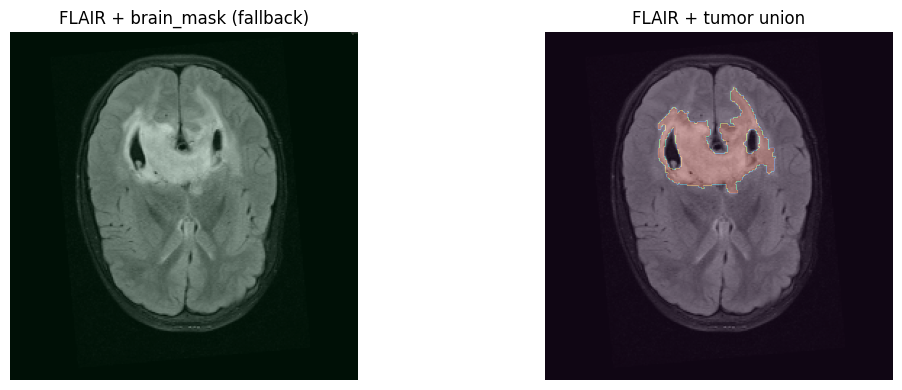


NOTE: If hd-bet is available/installed, we will switch to true skull stripping in the next cell and store brain masks on disk for preprocessing.


In [36]:
# Section 2.2 — Skull stripping (mandatory): HD-BET if available, else conservative fallback

import shutil


def build_conservative_brain_mask(vols: dict) -> np.ndarray:
    """Fallback mask: union of non-zero voxels across modalities.

    This is NOT true skull stripping; it is a conservative proxy.
    We explicitly validate tumor remains inside the mask.
    """
    m = np.zeros_like(vols["t1"], dtype=bool)
    for k in ["t1", "t1ce", "t2", "flair"]:
        m |= vols[k] > 0
    return m


# Detect HD-BET CLI
hd_bet_cli = shutil.which("hd-bet") or shutil.which("HD-BET")
print("HD-BET CLI:", hd_bet_cli if hd_bet_cli else "NOT FOUND")

# For now we demonstrate on the in-memory train_vols from Section 1C
brain_mask = build_conservative_brain_mask(train_vols)

print("brain_mask shape:", brain_mask.shape)
print("brain_mask coverage (fraction):", float(brain_mask.mean()))

# Safety check: tumor should not lie outside mask
if "seg" in train_vols:
    tumor = train_vols["seg"] > 0
    outside = tumor & (~brain_mask)
    frac_outside = float(outside.sum() / (tumor.sum() + 1e-8))
    print("tumor voxels:", int(tumor.sum()))
    print("tumor outside mask:", int(outside.sum()), "fraction:", frac_outside)
    if frac_outside > 1e-4:
        raise RuntimeError(
            "Conservative brain mask excludes tumor voxels. Stop and fix skull stripping/mask creation before continuing."
        )

# Visualize mask boundary + tumor overlay on FLAIR
z = train_vols["t1"].shape[2] // 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(train_vols["flair"][:, :, z].T, cmap="gray", origin="lower")
ax[0].imshow(brain_mask[:, :, z].T, cmap="Greens", origin="lower", alpha=0.25)
ax[0].set_title("FLAIR + brain_mask (fallback)")
ax[0].axis("off")

ax[1].imshow(train_vols["flair"][:, :, z].T, cmap="gray", origin="lower")
if "seg" in train_vols:
    ax[1].imshow((train_vols["seg"] > 0)[:, :, z].T, cmap="turbo", origin="lower", alpha=0.35)
ax[1].set_title("FLAIR + tumor union")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print(
    "\nNOTE: If hd-bet is available/installed, we will switch to true skull stripping in the next cell "
    "and store brain masks on disk for preprocessing."
)


t1: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)
t1ce: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)
t2: normed mean=0.0000, std=1.0000, shape=(240, 240, 155)
flair: normed mean=-0.0000, std=1.0000, shape=(240, 240, 155)


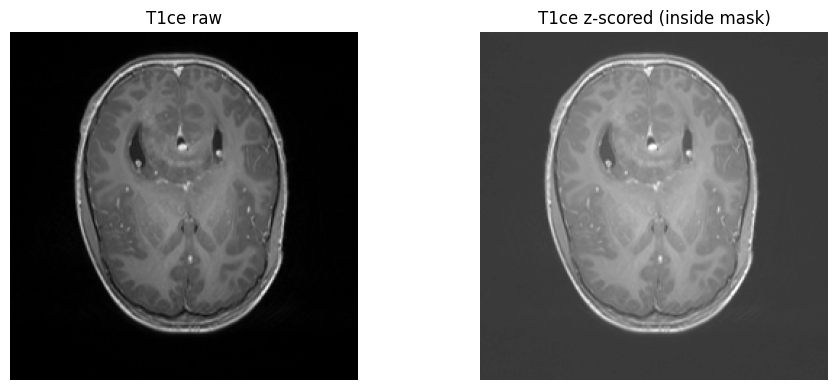


Preprocessing sanity complete for sample. Next: implement on-disk preprocessing + nnU-Net v2 baseline.


In [37]:
# Section 2.3 — Intensity normalization inside brain mask (per-modality, per-subject)

import numpy as np


def zscore_normalize_in_mask(x: np.ndarray, mask: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32, copy=False)
    vals = x[mask]
    mu = float(vals.mean()) if vals.size else float(x.mean())
    sd = float(vals.std()) if vals.size else float(x.std())
    sd = sd + 1e-8
    return (x - mu) / sd


normed = {}
for k in ["t1", "t1ce", "t2", "flair"]:
    normed[k] = zscore_normalize_in_mask(train_vols[k], brain_mask)
    inside = normed[k][brain_mask]
    print(f"{k}: normed mean={float(inside.mean()):.4f}, std={float(inside.std()):.4f}, shape={normed[k].shape}")

# Visual sanity: before/after for one modality
z = train_vols["t1"].shape[2] // 2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(train_vols["t1ce"][:, :, z].T, cmap="gray", origin="lower")
ax[0].set_title("T1ce raw")
ax[0].axis("off")

ax[1].imshow(normed["t1ce"][:, :, z].T, cmap="gray", origin="lower", vmin=-2, vmax=4)
ax[1].set_title("T1ce z-scored (inside mask)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("\nPreprocessing sanity complete for sample. Next: implement on-disk preprocessing + nnU-Net v2 baseline.")


## Section 3 — nnU‑Net v2 Baseline (Setup)

**Goal:** set up nnU‑Net v2 and convert the dataset to nnU‑Net v2 raw format.

**Important constraints:**
- All commands run in this notebook (no terminal-first workflow).
- We will **apply the inferred `LABEL_MAPPING`** to training labels when exporting labels for nnU‑Net.
- Server validation appears unlabeled; we’ll use nnU‑Net CV for baseline metrics, and (optionally) create an internal holdout split later for stricter gating.


In [38]:
# Section 3.1 — Install & validate nnU‑Net v2 (in-notebook)

import os
import sys
import shlex
import shutil
import subprocess
from pathlib import Path


def _run(cmd, check=True):
    """Run a shell command from within notebook and stream output."""
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {p.returncode}: {cmd}")


# nnU-Net v2 import probe
try:
    import nnunetv2  # noqa: F401
    has_nnunet = True
except Exception as e:
    has_nnunet = False
    print("nnunetv2 import failed:", repr(e))


if not has_nnunet:
    print("Installing nnunetv2 via pip (this may take a minute)...")
    _run(f"{shlex.quote(sys.executable)} -m pip install -U nnunetv2")

    import nnunetv2  # noqa: F401
    has_nnunet = True

print("nnunetv2 import: OK")

# Validate CLIs are on PATH (kernel PATH may differ from system PATH)
clis = [
    "nnUNetv2_plan_and_preprocess",
    "nnUNetv2_train",
    "nnUNetv2_predict",
]
for c in clis:
    print(f"{c}:", shutil.which(c) or "NOT FOUND on PATH")

print("\nIf CLIs are NOT FOUND, restart the kernel once after install; entrypoints should then be visible. We can also fall back to module execution if needed.")


nnunetv2 import: OK
nnUNetv2_plan_and_preprocess: /usr/local/bin/nnUNetv2_plan_and_preprocess
nnUNetv2_train: /usr/local/bin/nnUNetv2_train
nnUNetv2_predict: /usr/local/bin/nnUNetv2_predict

If CLIs are NOT FOUND, restart the kernel once after install; entrypoints should then be visible. We can also fall back to module execution if needed.


In [39]:
# Section 3.2 — Configure nnU‑Net v2 environment paths

from pathlib import Path
import os


def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p


# Base path: keep everything under the dataset root for locality
# training_main_dir is expected to be a PosixPath like /workspace/pediatric_tumor_data/training/...
base_root = Path(str(training_main_dir)).parents[1]  # /workspace/pediatric_tumor_data
nnunet_base = _ensure_dir(base_root / "nnunetv2")

nnUNet_raw = _ensure_dir(nnunet_base / "nnUNet_raw")
nnUNet_preprocessed = _ensure_dir(nnunet_base / "nnUNet_preprocessed")
nnUNet_results = _ensure_dir(nnunet_base / "nnUNet_results")

os.environ["nnUNet_raw"] = str(nnUNet_raw)
os.environ["nnUNet_preprocessed"] = str(nnUNet_preprocessed)
os.environ["nnUNet_results"] = str(nnUNet_results)

print("nnUNet_raw:", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed:", os.environ["nnUNet_preprocessed"])
print("nnUNet_results:", os.environ["nnUNet_results"])

# Dataset identifiers
DATASET_ID = 501
DATASET_NAME = "BraTS_PEDs2024"
DATASET_FOLDER = nnUNet_raw / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"

print("\nDataset folder:", DATASET_FOLDER)


nnUNet_raw: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw
nnUNet_preprocessed: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed
nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results

Dataset folder: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024


In [40]:
# Section 3.3 — Export BraTS PEDs dataset to nnU‑Net v2 raw format (with label remap)

import os
import re
import json
import shutil
import numpy as np
import nibabel as nib
from pathlib import Path


# Safer default for reruns: do not rebuild unless explicitly requested.
OVERWRITE_DATASET = False


def _safe_mkdir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)


def _count_nii_gz(p: Path) -> int:
    return len(list(p.glob("*.nii.gz")))


def _link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.link(str(src), str(dst))
    except Exception:
        shutil.copy2(str(src), str(dst))


# Export-time modality matching. We cannot rely on older in-kernel patterns.
# Supports both BraTS2025-style tokens (t1n/t1c/t2w/t2f) and common aliases.
EXPORT_MODALITY_PATTERNS = {
    "t1": [re.compile(r"(^|[^a-z0-9])t1n([^a-z0-9]|$)"), re.compile(r"(^|[^a-z0-9])t1([^a-z0-9]|$)")],
    "t1ce": [re.compile(r"(^|[^a-z0-9])t1c([^a-z0-9]|$)"), re.compile(r"t1ce|t1gd|t1c\b")],
    "t2": [re.compile(r"(^|[^a-z0-9])t2w([^a-z0-9]|$)"), re.compile(r"(^|[^a-z0-9])t2([^a-z0-9]|$)")],
    "flair": [re.compile(r"(^|[^a-z0-9])t2f([^a-z0-9]|$)"), re.compile(r"flair")],
}


def _any_match(pats, text: str) -> bool:
    for p in pats:
        if p.search(text):
            return True
    return False


def _index_case_files(case_dir: Path):
    """Return ({modality_key: path}, seg_path_or_None)."""
    files = list(case_dir.glob("*.nii")) + list(case_dir.glob("*.nii.gz"))
    if not files:
        raise FileNotFoundError(f"No NIfTI files in {case_dir}")

    mods = {}
    seg = None

    for f in files:
        name = f.name.lower()
        if "seg" in name and (".nii" in name):
            seg = f
            continue

        for mod_key, pats in EXPORT_MODALITY_PATTERNS.items():
            if _any_match(pats, name):
                mods[mod_key] = f
                break

    return mods, seg


def _load_and_remap_seg(seg_path: Path, mapping: dict) -> nib.Nifti1Image:
    img = nib.load(str(seg_path))
    data = img.get_fdata(dtype=np.float32)

    rounded = np.rint(data)
    max_abs_err = float(np.max(np.abs(data - rounded)))
    if max_abs_err > 1e-3:
        raise ValueError(f"Seg appears non-integer-coded: max_abs_err={max_abs_err} at {seg_path}")

    seg_int = rounded.astype(np.int16)

    out = np.zeros_like(seg_int, dtype=np.int16)
    for k, v in mapping.items():
        out[seg_int == int(k)] = int(v)

    uniq = set(np.unique(out).tolist())
    allowed = {0, 1, 2, 4}
    if not uniq.issubset(allowed):
        raise ValueError(f"Remapped seg contains unexpected labels {sorted(uniq)} from {seg_path}")

    return nib.Nifti1Image(out, img.affine, img.header)


# Paths
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

expected_imagesTr = 4 * len(train_cases)
expected_labelsTr = len(train_cases)
expected_imagesTs = 4 * len(val_cases)

if DATASET_FOLDER.exists() and not OVERWRITE_DATASET:
    if (DATASET_FOLDER / "dataset.json").exists() and imagesTr.exists() and labelsTr.exists() and imagesTs.exists():
        n_imgsTr = _count_nii_gz(imagesTr)
        n_lblsTr = _count_nii_gz(labelsTr)
        n_imgsTs = _count_nii_gz(imagesTs)

        if (n_imgsTr, n_lblsTr, n_imgsTs) == (expected_imagesTr, expected_labelsTr, expected_imagesTs):
            print("nnU-Net raw export already present; skipping rebuild.")
            print("imagesTr:", n_imgsTr, "labelsTr:", n_lblsTr, "imagesTs:", n_imgsTs)
            n_train_written = expected_labelsTr
            n_val_written = len(val_cases)
        else:
            raise RuntimeError(
                "Dataset folder exists but counts do not match expected. "
                f"Found imagesTr={n_imgsTr} labelsTr={n_lblsTr} imagesTs={n_imgsTs}; "
                f"expected imagesTr={expected_imagesTr} labelsTr={expected_labelsTr} imagesTs={expected_imagesTs}. "
                "Set OVERWRITE_DATASET=True to rebuild."
            )
    else:
        raise RuntimeError(
            "Dataset folder exists but is missing expected subfolders/files. "
            "Set OVERWRITE_DATASET=True to rebuild."
        )


if OVERWRITE_DATASET:
    if DATASET_FOLDER.exists():
        shutil.rmtree(DATASET_FOLDER)

    for p in [imagesTr, labelsTr, imagesTs]:
        _safe_mkdir(p)

    channel_order = ["t1", "t1ce", "t2", "flair"]
    channel_names = {str(i): name for i, name in enumerate(["T1", "T1ce", "T2", "FLAIR"])}
    label_names = {"background": 0, "TC": 1, "ED": 2, "ET": 4}

    n_train_written = 0
    missing_train = 0

    for case_dir in train_cases:
        case_dir = Path(str(case_dir))
        case_id = case_dir.name

        mods, seg = _index_case_files(case_dir)

        missing = [m for m in channel_order if m not in mods]
        if missing or seg is None:
            missing_train += 1
            continue

        for i, mod_key in enumerate(channel_order):
            src = mods[mod_key]
            dst = imagesTr / f"{case_id}_{i:04d}.nii.gz"
            _link_or_copy(src, dst)

        remapped = _load_and_remap_seg(seg, LABEL_MAPPING)
        nib.save(remapped, str(labelsTr / f"{case_id}.nii.gz"))

        n_train_written += 1

    print(f"Training exported: {n_train_written} cases")
    print(f"Training skipped (missing data): {missing_train} cases")

    n_val_written = 0
    missing_val = 0

    for case_dir in val_cases:
        case_dir = Path(str(case_dir))
        case_id = case_dir.name

        mods, seg = _index_case_files(case_dir)

        missing = [m for m in channel_order if m not in mods]
        if missing:
            missing_val += 1
            continue

        for i, mod_key in enumerate(channel_order):
            src = mods[mod_key]
            dst = imagesTs / f"{case_id}_{i:04d}.nii.gz"
            _link_or_copy(src, dst)

        n_val_written += 1

    print(f"imagesTs exported: {n_val_written} cases")
    print(f"imagesTs skipped (missing data): {missing_val} cases")

    dataset_json_path = DATASET_FOLDER / "dataset.json"
    dataset_json = {
        "name": DATASET_NAME,
        "description": "BraTS PEDs export with label remap to {0,1,2,4}",
        "tensorImageSize": "3D",
        "reference": "BraTS PEDs",
        "licence": "unknown",
        "release": "0.0",
        "channel_names": channel_names,
        "labels": {k: int(v) for k, v in label_names.items()},
        "numTraining": int(n_train_written),
        "file_ending": ".nii.gz",
    }

    dataset_json_path.write_text(json.dumps(dataset_json, indent=2))
    print("Wrote:", dataset_json_path)


nnU-Net raw export already present; skipping rebuild.
imagesTr: 1044 labelsTr: 261 imagesTs: 364


In [41]:
# Section 3.4 — Sanity-check nnU‑Net export

from pathlib import Path

imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

def _count(pattern, root):
    return len(list(Path(root).glob(pattern)))

n_imgsTr = _count("*.nii.gz", imagesTr)
n_lblsTr = _count("*.nii.gz", labelsTr)
n_imgsTs = _count("*.nii.gz", imagesTs)

print("Dataset:", DATASET_FOLDER.name)
print("imagesTr NIfTI:", n_imgsTr)
print("labelsTr NIfTI:", n_lblsTr)
print("imagesTs NIfTI:", n_imgsTs)

# Each training case should contribute 4 images + 1 label
if n_lblsTr > 0:
    est_train_cases = n_imgsTr // 4
    print("Estimated training cases from imagesTr:", est_train_cases)
    print("Label files:", n_lblsTr)
    if est_train_cases != n_lblsTr:
        print("WARNING: imagesTr/labelsTr case count mismatch.")

# Quick spot-check a few label uniques (remapped ontology)
import random
import numpy as np
import nibabel as nib

lbl_paths = sorted(list(labelsTr.glob("*.nii.gz")))
for p in random.sample(lbl_paths, k=min(3, len(lbl_paths))):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    uniq = np.unique(arr)
    print(p.name, "unique labels:", uniq[:20], "(n=", len(uniq), ")")


Dataset: Dataset501_BraTS_PEDs2024
imagesTr NIfTI: 1044
labelsTr NIfTI: 261
imagesTs NIfTI: 364
Estimated training cases from imagesTr: 261
Label files: 261
BraTS-PED-00193-000.nii.gz unique labels: [0 2 4] (n= 3 )
BraTS-PED-00088-000.nii.gz unique labels: [0 1 2 4] (n= 4 )
BraTS-PED-00176-000.nii.gz unique labels: [0 1 2 4] (n= 4 )


In [42]:
# Section 3.6 — nnU‑Net v2 planning/preprocessing + training commands
# NOTE: These steps are compute-heavy. Start with planning/preprocessing; then train fold 0.

import subprocess


def run_cmd(cmd: str, check: bool = True):
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")


DATASET_ID = int(DATASET_ID)

plan_cmd = f"nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity"
train_cmd = f"nnUNetv2_train {DATASET_ID} 3d_fullres 0"

print("Planned commands:")
print(" -", plan_cmd)
print(" -", train_cmd)

# Uncomment to run:
# run_cmd(plan_cmd)
# run_cmd(train_cmd)


Planned commands:
 - nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity
 - nnUNetv2_train 501 3d_fullres 0


## Section 3.7 — nnU‑Net v2 Planning/Preprocessing (Run)

This will run nnU‑Net v2 dataset verification + planning + preprocessing for Dataset 501.

- This can take a while.
- If it fails, we stop and fix the root cause before training.


In [44]:
# Section 3.7.0 — nnU‑Net label fix: make labels consecutive (ET 4 -> 3)
# nnU‑Net v2 requires labels to be consecutive: {0,1,2,3,...}
# Our BraTS-style export uses {0,1,2,4}, so we convert ET=4 -> 3 for nnU‑Net.

import json
import numpy as np
import nibabel as nib
from pathlib import Path


labelsTr = DATASET_FOLDER / "labelsTr"
dataset_json_path = DATASET_FOLDER / "dataset.json"


def _unique_labels_in_file(p: Path) -> set:
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return set(np.unique(arr).tolist())


def _rewrite_et_4_to_3(p: Path) -> bool:
    img = nib.load(str(p))
    arr = np.asanyarray(img.dataobj).astype(np.int16)
    if 4 not in arr:
        return False
    arr = arr.copy()
    arr[arr == 4] = 3
    nib.save(nib.Nifti1Image(arr, img.affine, img.header), str(p))
    return True


lbl_files = sorted(labelsTr.glob("*.nii.gz"))
if len(lbl_files) == 0:
    raise RuntimeError(f"No label files found in {labelsTr}")

# Quick scan a subset to see if conversion is needed
sample_files = lbl_files[:: max(1, len(lbl_files)//10)]
uniqs = set()
for p in sample_files:
    uniqs |= _unique_labels_in_file(p)

print("Sampled unique labels (pre):", sorted(uniqs))

if 4 in uniqs:
    changed = 0
    for p in lbl_files:
        if _rewrite_et_4_to_3(p):
            changed += 1
    print("Converted ET 4->3 in label files touched:", changed)
else:
    print("No 4 detected in sample; assuming labels are already consecutive.")

# Verify a few files again
uniqs_post = set()
for p in sample_files:
    uniqs_post |= _unique_labels_in_file(p)
print("Sampled unique labels (post):", sorted(uniqs_post))

# Update dataset.json labels mapping for nnU-Net
if dataset_json_path.exists():
    ds = json.loads(dataset_json_path.read_text())
    if "labels" in ds and "ET" in ds["labels"]:
        ds["labels"]["ET"] = 3
        dataset_json_path.write_text(json.dumps(ds, indent=2))
        print("Updated dataset.json: ET=3")

# Store mapping so later evaluation can map nnU-Net ET(3) back to BraTS ET(4) if needed
NNUNET_LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 4}
print("NNUNET_LABEL_MAP (nnU-Net -> BraTS):", NNUNET_LABEL_MAP)


Sampled unique labels (pre): [0, 1, 2, 4]
Converted ET 4->3 in label files touched: 192
Sampled unique labels (post): [0, 1, 2, 3]
Updated dataset.json: ET=3
NNUNET_LABEL_MAP (nnU-Net -> BraTS): {0: 0, 1: 1, 2: 2, 3: 4}


In [48]:
# Section 3.7.0b — Fix nnU‑Net raw images that are named `.nii.gz` but are not gzip
# nnU-Net uses SimpleITK; SimpleITK will fail if a file ends with `.nii.gz` but is not actually gzip.
# We fix this by rewriting such files as real gzip-compressed files.
# IMPORTANT: nnU‑Net exports may be hardlinks to the source dataset. We always rewrite via atomic
# replace (temp file + os.replace) so we break hardlinks and never mutate the original dataset.

import os
import gzip
import shutil
from pathlib import Path


imagesTr = DATASET_FOLDER / "imagesTr"
imagesTs = DATASET_FOLDER / "imagesTs"


def is_gzip_file(path: Path) -> bool:
    try:
        with gzip.open(path, "rb") as f:
            f.read(1)
        return True
    except Exception:
        return False


def rewrite_as_gzip(path: Path) -> None:
    """Wrap raw bytes of `path` into a gzip stream and atomically replace the file."""
    tmp = path.with_suffix(path.suffix + ".tmp")  # *.nii.gz.tmp

    # Read raw bytes from the current file (may be uncompressed NIfTI but misnamed)
    with open(path, "rb") as fin, gzip.open(tmp, "wb") as fout:
        shutil.copyfileobj(fin, fout)

    # Atomic replace breaks hardlinks and avoids partial writes.
    os.replace(str(tmp), str(path))


def fix_folder(folder: Path) -> int:
    fixed = 0
    for p in sorted(folder.glob("*.nii.gz")):
        if not is_gzip_file(p):
            rewrite_as_gzip(p)
            fixed += 1
    return fixed


# Fix both train/test image folders
fixed_tr = fix_folder(imagesTr)
fixed_ts = fix_folder(imagesTs)

print("Fixed mislabeled .nii.gz (not gzip):")
print(" - imagesTr:", fixed_tr)
print(" - imagesTs:", fixed_ts)

# Sanity check: known previously failing file should now be gzip
known = imagesTr / "BraTS-PED-00255-000_0001.nii.gz"
print("Known file gzip now:", is_gzip_file(known))


Fixed mislabeled .nii.gz (not gzip):
 - imagesTr: 1
 - imagesTs: 0
Known file gzip now: True


In [56]:
# Section 3.7.0c — Targeted fix for a SimpleITK-unreadable file

# If the source file is corrupt (not a real NIfTI), we quarantine the entire case from nnU-Net export
# and update dataset.json (numTraining / optional training list) accordingly.

import json
import os
import shutil
import nibabel as nib
import SimpleITK as sitk
from pathlib import Path

# Known failing nnU-Net file from integrity check
bad = Path("/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTr/BraTS-PED-00255-000_0001.nii.gz")

# Corresponding source modality in original dataset (channel 0001 -> T1c)
src = Path(str(training_main_dir)) / "BraTS-PED-00255-000" / "BraTS-PED-00255-000-t1c.nii.gz"

case_id = "BraTS-PED-00255-000"
imagesTr_dir = bad.parent
dataset_root = imagesTr_dir.parent
labelsTr_dir = dataset_root / "labelsTr"
dataset_json_path = dataset_root / "dataset.json"

def _case_ids_from_labels(labels_dir: Path) -> list[str]:
    ids: list[str] = []
    for f in sorted(labels_dir.glob("*.nii.gz")):
        ids.append(f.name.removesuffix(".nii.gz"))
    return ids

def update_dataset_json_num_training():
    if not dataset_json_path.exists():
        print("[WARN] dataset.json not found at", dataset_json_path)
        return
    with open(dataset_json_path, "r") as f:
        js = json.load(f)
    case_ids = _case_ids_from_labels(labelsTr_dir)
    js["numTraining"] = len(case_ids)
    if isinstance(js.get("training"), list):
        kept = []
        for item in js["training"]:
            lbl = (item.get("label") or "")
            ok = any(cid in lbl for cid in case_ids)
            if ok:
                kept.append(item)
        js["training"] = kept
    with open(dataset_json_path, "w") as f:
        json.dump(js, f, indent=2)
    print(f"[OK] Updated dataset.json numTraining={js['numTraining']}")

def quarantine_case(case_id: str, reason: str):
    qroot = dataset_root / "quarantine_corrupt"
    q_images = qroot / "imagesTr"
    q_labels = qroot / "labelsTr"
    q_images.mkdir(parents=True, exist_ok=True)
    q_labels.mkdir(parents=True, exist_ok=True)
    moved = []
    for f in sorted(imagesTr_dir.glob(f"{case_id}_000*.nii.gz")):
        dst = q_images / f.name
        os.replace(str(f), str(dst))
        moved.append(dst)
    lbl = labelsTr_dir / f"{case_id}.nii.gz"
    if lbl.exists():
        dst = q_labels / lbl.name
        os.replace(str(lbl), str(dst))
        moved.append(dst)
    print(f"[QUARANTINE] {case_id}: {reason}")
    print(f"[QUARANTINE] moved {len(moved)} file(s) to {qroot}")
    for m in moved:
        print("  -", m)
    update_dataset_json_num_training()
    return moved

print("case:", case_id)
print("bad:", bad)
print("src:", src)
print("bad exists:", bad.exists(), "src exists:", src.exists())
if src.exists():
    print("src size (bytes):", src.stat().st_size)
if bad.exists():
    print("bad size (bytes):", bad.stat().st_size)

if not src.exists():
    raise FileNotFoundError(f"Source missing: {src}")

# If we've already quarantined the case, just ensure dataset.json is consistent.
if not bad.exists():
    print("[INFO] bad file not present (likely already quarantined).")
    update_dataset_json_num_training()
else:
    # Attempt to rewrite bad from src. If that fails, quarantine the case.
    tmp_dir = imagesTr_dir / "_repair_tmp"
    tmp_dir.mkdir(parents=True, exist_ok=True)
    src_tmp_nii = tmp_dir / (src.name.removesuffix(".nii.gz") + ".nii")
    out_tmp = tmp_dir / bad.name

    # Copy source bytes without touching the original file
    shutil.copyfile(src, src_tmp_nii)

    wrote = False
    errors = []

    # Attempt 1: nibabel (often works for uncompressed NIfTI)
    try:
        img = nib.load(str(src_tmp_nii))
        nib.save(img, str(out_tmp))
        wrote = True
        print("[OK] Rewrote via nibabel.")
    except Exception as e:
        errors.append(f"nibabel: {e}")

    # Attempt 2: SimpleITK fallback
    if not wrote:
        try:
            img = sitk.ReadImage(str(src_tmp_nii))
            sitk.WriteImage(img, str(out_tmp))
            wrote = True
            print("[OK] Rewrote via SimpleITK.")
        except Exception as e:
            errors.append(f"SimpleITK: {e}")

    if wrote:
        # Atomically replace to break any hardlink and ensure nnU-Net sees the repaired file
        os.replace(str(out_tmp), str(bad))
        # Validate with SimpleITK
        _ = sitk.ReadImage(str(bad))
        print("[OK] SimpleITK can read the repaired file.")
    else:
        # Diagnostics: show magic bytes and NIfTI header hints
        with open(src_tmp_nii, "rb") as f:
            head = f.read(512)
        magic2 = head[:2]
        magic4 = head[:4]
        nifti_magic = head[344:348] if len(head) >= 348 else b""
        print("[DIAG] first2:", magic2, "first4:", magic4, "nifti_magic@344:", nifti_magic)
        quarantine_case(case_id, reason="; ".join(errors))

case: BraTS-PED-00255-000
bad: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw/Dataset501_BraTS_PEDs2024/imagesTr/BraTS-PED-00255-000_0001.nii.gz
src: /workspace/pediatric_tumor_data/training/BraTS-PEDs2024_Training/BraTS-PED-00255-000/BraTS-PED-00255-000-t1c.nii.gz
bad exists: False src exists: True
src size (bytes): 20492405
[INFO] bad file not present (likely already quarantined).
[OK] Updated dataset.json numTraining=260


In [57]:
# Section 3.7.1 — Run nnU-Net v2 planning + preprocessing

import os
import subprocess


def _cmd_help_contains(cmd: str, needle: str) -> bool:
    try:
        p = subprocess.run([cmd, "-h"], capture_output=True, text=True)
        txt = (p.stdout or "") + "\n" + (p.stderr or "")
        return needle in txt
    except Exception:
        return False


def run_cmd(cmd: str, check: bool = True):
    print(f"$ {cmd}")
    p = subprocess.run(cmd, shell=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")


# Keep preprocessing reasonably parallel but not insane by default.
# You can tune these if your server has more/less CPU cores.
os.environ.setdefault("nnUNet_n_proc_DA", "8")

use_c_flag = _cmd_help_contains("nnUNetv2_plan_and_preprocess", "-c")

base = f"nnUNetv2_plan_and_preprocess -d {int(DATASET_ID)} --verify_dataset_integrity"
cmd = base + (" -c 3d_fullres" if use_c_flag else "")

print("Will run:")
print(cmd)

run_cmd(cmd)
print("\n[OK] Planning/preprocessing completed.")


Will run:
nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity -c 3d_fullres
$ nnUNetv2_plan_and_preprocess -d 501 --verify_dataset_integrity -c 3d_fullres
Fingerprint extraction...
Dataset501_BraTS_PEDs2024
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer


100%|██████████| 260/260 [00:44<00:00,  5.82it/s]


Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [155. 240. 222.], 3d_lowres: [155, 240, 222]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 56, 'patch_size': (256, 224), 'median_image_size_in_voxels': array([240., 222.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [False, False, False, False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': F

100%|██████████| 260/260 [10:16<00:00,  2.37s/it]



[OK] Planning/preprocessing completed.


## Section 3.8 — nnU‑Net v2 Baseline Training (Start)

We’ll start **fold 0** training for `3d_fullres`.

Training can take hours; to keep the notebook responsive, we launch training in the background and write logs to disk.


### Citation (nnU‑Net)
If you use nnU‑Net in this project, please cite:
- Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). *nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation*. **Nature Methods, 18**(2), 203–211.

### Speed notes (why epochs can differ by fold)
In nnU‑Net v2, different folds **should not** be ~5× slower by themselves if config/hardware are unchanged. Big slowdowns are usually due to:
- Running a different config (e.g., `2d` vs `3d_fullres`)
- GPU starving (data augmentation / I/O bottleneck)
- Environment flags like `nnUNet_n_proc_DA` (augmentation workers) or `nnUNet_compile=0`
- Running on a smaller/contended MIG slice (or CPU-only by accident)


In [ ]:
# Speed tuning / diagnostics (run BEFORE launching a fold)
import os
import shutil
import subprocess
import multiprocessing
print("CPU cores:", multiprocessing.cpu_count())
print("nnUNet_n_proc_DA:", os.environ.get("nnUNet_n_proc_DA"))
print("nnUNet_compile:", os.environ.get("nnUNet_compile"))
print()
print("Tips:")
print("- If GPU is starved, try: os.environ['nnUNet_n_proc_DA']='8' (or '12' if you have CPU/RAM)")
print("- If you previously set nnUNet_compile=0 for stability, consider removing it for speed")
print("- These env vars only affect NEW training processes (they won't change a fold already running).")
print()
if shutil.which("nvidia-smi"):
    print("nvidia-smi -L:")
    subprocess.run("nvidia-smi -L", shell=True, check=False)
    print("\nQuick utilization sampling (may be limited under MIG/permissions):")
    # dmon often works better than the default table under MIG
    subprocess.run("nvidia-smi dmon -s pucvmt -d 1 -c 5", shell=True, check=False)
else:
    print("nvidia-smi not available in this kernel environment.")

In [58]:
# Section 3.8.1 — Launch nnU-Net training fold 0 in background (log to file)

import os
import time
import subprocess
from pathlib import Path


def _timestamp() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

log_path = run_root / f"nnunetv2_train_d{int(DATASET_ID)}_3d_fullres_fold0_{_timestamp()}.log"

train_cmd = [
    "nnUNetv2_train",
    str(int(DATASET_ID)),
    "3d_fullres",
    "0",
]

print("Launching:")
print(" ".join(train_cmd))
print("Log:", str(log_path))

with open(log_path, "w", buffering=1) as f:
    train_proc = subprocess.Popen(train_cmd, stdout=f, stderr=subprocess.STDOUT, text=True)

print("Started PID:", train_proc.pid)
print("\nUse the next cell to monitor logs and confirm it’s progressing.")


Launching:
nnUNetv2_train 501 3d_fullres 0
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
Started PID: 1128629

Use the next cell to monitor logs and confirm it’s progressing.


In [64]:
# Section 3.8.2 — Monitor training log (tail + status)

import os
import time
import subprocess
from pathlib import Path


def tail(path: Path, n: int = 80) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(log not found yet: {path})"


print("Log:", str(log_path))
if log_path.exists():
    st = log_path.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(log file does not exist yet)")

print("\n--- tail ---")
print(tail(log_path, n=120) or "(no text yet)")

alive = train_proc.poll() is None
print("\nProcess alive:", alive)
print("PID:", train_proc.pid)
if alive:
    try:
        # Lightweight sanity check that the PID is still present
        r = subprocess.run(["ps", "-p", str(train_proc.pid), "-o", "pid,etime,cmd"], capture_output=True, text=True)
        print("\n--- ps ---")
        print((r.stdout or r.stderr).strip())
    except Exception as e:
        print("[WARN] Could not query process status:", e)
else:
    print("Exit code:", train_proc.returncode)
    print("If the log is empty, it may have failed very early.")

Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
size=1052 bytes  mtime=2026-01-08 02:18:04

--- tail ---

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-01-08 02:17:59.670449: Using torch.compile...
2026-01-08 02:18:00.380803: do_dummy_2d_data_aug: False


In [61]:
# Section 3.8.3 — (Optional) Schedule folds 1–4 sequentially after fold 0 completes

import os
import time
import subprocess
from pathlib import Path


def _timestamp() -> str:
    return time.strftime("%Y%m%d_%H%M%S")


run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

pid0 = int(train_proc.pid)
dataset_id = int(DATASET_ID)
config = "3d_fullres"

script_path = run_root / f"nnunetv2_schedule_folds1to4_after_fold0_{_timestamp()}.sh"
scheduler_log = run_root / f"nnunetv2_scheduler_{_timestamp()}.log"

script = f"""#!/usr/bin/env bash
set -euo pipefail

export PYTHONUNBUFFERED=1

echo "[scheduler] waiting for fold0 pid={pid0} at $(date)"
while kill -0 {pid0} >/dev/null 2>&1; do
  sleep 60
done
echo "[scheduler] fold0 finished at $(date)"

for fold in 1 2 3 4; do
  log=\"{run_root}/nnunetv2_train_d{dataset_id}_{config}_fold${{fold}}_{_timestamp()}.log\"
  echo "[scheduler] starting fold=${{fold}} at $(date); log=${{log}}"
  nnUNetv2_train {dataset_id} {config} ${{fold}} > \"${{log}}\" 2>&1
  echo "[scheduler] finished fold=${{fold}} at $(date)"
done

echo "[scheduler] all folds done at $(date)"
"""

script_path.write_text(script)
script_path.chmod(0o755)

print("Wrote scheduler script:", script_path)
print("Scheduler log:", scheduler_log)
print("This will NOT start new folds until fold 0 (PID above) exits.")

# Start in background (persists independently of the notebook cell)
cmd = f"nohup bash {script_path} > {scheduler_log} 2>&1 & echo $!"
print("$", cmd)
out = subprocess.check_output(cmd, shell=True, text=True).strip()
scheduler_pid = int(out)
print("Started scheduler PID:", scheduler_pid)

Wrote scheduler script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_schedule_folds1to4_after_fold0_20260108_022143.sh
Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log
This will NOT start new folds until fold 0 (PID above) exits.
$ nohup bash /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_schedule_folds1to4_after_fold0_20260108_022143.sh > /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log 2>&1 & echo $!
Started scheduler PID: 1132222


In [65]:
# Section 3.8.4 — Monitor scheduler log (tail + status)

import time
import subprocess
from pathlib import Path


def tail(path: Path, n: int = 120) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(log not found yet: {path})"


print("Scheduler log:", str(scheduler_log))
if scheduler_log.exists():
    st = scheduler_log.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(scheduler log file does not exist yet)")

print("\n--- tail ---")
print(tail(scheduler_log, n=200) or "(no text yet)")

alive = subprocess.run(["bash", "-lc", f"kill -0 {int(scheduler_pid)} 2>/dev/null"], capture_output=True).returncode == 0
print("\nScheduler alive:", alive)
print("Scheduler PID:", int(scheduler_pid))

Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_scheduler_20260108_022143.log
size=74 bytes  mtime=2026-01-08 02:21:43

--- tail ---
[scheduler] waiting for fold0 pid=1128629 at Thu Jan  8 02:21:43 UTC 2026


Scheduler alive: True
Scheduler PID: 1132222


In [66]:
# Section 3.8.5 — Training progress snapshot (server-side only)

import os
import time
import shutil
import subprocess
from pathlib import Path


def _run(cmd: str) -> None:
    print("$", cmd)
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    out = ((p.stdout or "") + (p.stderr or "")).strip()
    print(out if out else "(no output)")
    print()


print("Time:", time.strftime("%Y-%m-%d %H:%M:%S"))
print("CWD:", os.getcwd())
print()

# 1) GPU status
if shutil.which("nvidia-smi"):
    _run("nvidia-smi --query-gpu=index,name,utilization.gpu,utilization.memory,memory.used,memory.total --format=csv")
else:
    print("nvidia-smi not found in this notebook environment.")
    try:
        import torch
        print("torch.cuda.is_available():", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("device:", torch.cuda.get_device_name(0))
            print("mem_allocated (GiB):", round(torch.cuda.memory_allocated(0) / (1024**3), 3))
            print("mem_reserved  (GiB):", round(torch.cuda.memory_reserved(0) / (1024**3), 3))
    except Exception as e:
        print("torch GPU check failed:", e)
print()

# 2) Training process status
pid = int(train_proc.pid)
print("train pid:", pid)
_run(f"ps -p {pid} -o pid,etime,pcpu,pmem,stat,cmd")

# 3) Log freshness
print("train log:", str(log_path))
if log_path.exists():
    st = log_path.stat()
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
else:
    print("(log missing)")
print()

# 4) nnU-Net results folder activity (more reliable than logs)
results_root = Path(os.environ.get("nnUNet_results", ""))
print("nnUNet_results:", str(results_root))
if results_root.exists():
    # Best-effort locate the fold0 output directory
    ds_prefix = f"Dataset{int(DATASET_ID):03d}_"
    ds_dirs = sorted([p for p in results_root.iterdir() if p.is_dir() and p.name.startswith(ds_prefix)])
    print("dataset dirs:", [p.name for p in ds_dirs])
    # Find recent files under any matching dataset dir (limit for speed)
    recent = []
    for ds in ds_dirs:
        for p in ds.rglob("*"):
            if p.is_file():
                try:
                    recent.append((p.stat().st_mtime, p))
                except FileNotFoundError:
                    pass
    recent.sort(key=lambda x: x[0], reverse=True)
    print("\nMost recent files under nnUNet_results (top 15):")
    for mtime, p in recent[:15]:
        print(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime)), "-", p)
else:
    print("(nnUNet_results path not found)")

Time: 2026-01-08 02:28:49
CWD: /workspace

$ nvidia-smi --query-gpu=index,name,utilization.gpu,utilization.memory,memory.used,memory.total --format=csv
index, name, utilization.gpu [%], utilization.memory [%], memory.used [MiB], memory.total [MiB]
0, NVIDIA H100 80GB HBM3, [N/A], [N/A], [Insufficient Permissions], [Insufficient Permissions]


train pid: 1128629
$ ps -p 1128629 -o pid,etime,pcpu,pmem,stat,cmd
PID     ELAPSED %CPU %MEM STAT CMD
1128629       10:58 75.1  0.1 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 0

train log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold0_20260108_021751.log
size=1052 bytes  mtime=2026-01-08 02:18:04

nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
dataset dirs: ['Dataset501_BraTS_PEDs2024']

Most recent files under nnUNet_results (top 15):
2026-01-08 02:28:14 - /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nn

results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
fold_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2026_1_8_02_17_59.txt
size=357152 bytes  mtime=2026-01-08 18:21:55

--- tail ---
2026-01-08 18:13:10.915110:  
2026-01-08 18:13:10.915911: Epoch 993 
2026-01-08 18:13:10.916467: Current learning rate: 0.00011 
2026-01-08 18:14:06.254988: train_loss -0.586 
2026-01-08 18:14:06.256240: val_loss -0.3434 
2026-01-08 18:14:06.256810: Pseudo dice [0.4374, 0.8265, 0.7112] 
2026-01-08 18:14:06.257365: Epoch time: 55.34 s 
2026-01-08 18:14:07.094173:  
2026-01-08 18:14:07.094860: Epoch 994 
2026-01-08 18:14:07.095387: Current learning rate: 0.0001 
2026-01-08 18:15:05.568974: train_loss -0.5835 
2026-01-08 18:15:05.571009: val_loss -0.3642 
2026-0

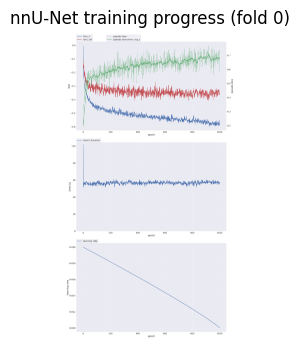

In [129]:
# Section 3.8.6 — Tail nnU-Net trainer log (authoritative) + show progress.png

import os
import time
from pathlib import Path


def _tail(path: Path, n: int = 120) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return f"(missing: {path})"


results_root = Path(os.environ["nnUNet_results"])
dataset_dir = results_root / f"Dataset{int(DATASET_ID):03d}_{DATASET_NAME}"
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
fold_dir = trainer_dir / "fold_0"

print("results_root:", results_root)
print("fold_dir:", fold_dir)

log_files = sorted(fold_dir.glob("training_log_*.txt"))
if not log_files:
    print("No training_log_*.txt found yet.")
else:
    log_file = log_files[-1]
    st = log_file.stat()
    print("log:", log_file)
    print(f"size={st.st_size} bytes  mtime={time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime))}")
    print("\n--- tail ---")
    print(_tail(log_file, n=160))

# Optional: show progress plot if available
png = fold_dir / "progress.png"
if png.exists():
    try:
        from PIL import Image
        import matplotlib.pyplot as plt
        img = Image.open(png)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title("nnU-Net training progress (fold 0)")
        plt.show()
    except Exception as e:
        print("[WARN] Could not display progress.png:", e)

In [14]:
# Section 3.8.8 — Resume after kernel reconnect (detect completed folds + run remaining folds 1–4 sequentially)

import os
import time
import subprocess
from pathlib import Path

# Hard-set nnU-Net paths (safe even if already set)
os.environ["nnUNet_raw"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"

results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

# Find dataset dir automatically (prefer Dataset501_*)
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* under {results_root}")
dataset_dir = ds_dirs[0]
dataset_id = 501
dataset_name = dataset_dir.name.removeprefix("Dataset501_")

trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
if not trainer_dir.exists():
    raise FileNotFoundError(f"Trainer dir not found: {trainer_dir}")

def fold_status(fold: int) -> dict:
    fdir = trainer_dir / f"fold_{fold}"
    return {
        "fold": fold,
        "dir": fdir,
        "exists": fdir.exists(),
        "checkpoint_final": (fdir / "checkpoint_final.pth").exists(),
        "checkpoint_best": (fdir / "checkpoint_best.pth").exists(),
        "progress_png": (fdir / "progress.png").exists(),
    }

folds = [fold_status(i) for i in range(5)]
print("Dataset:", dataset_dir.name)
print("Trainer:", trainer_dir)
print("\nFold status:")
for s in folds:
    print(
        f"fold_{s['fold']}: ",
"final" if s["checkpoint_final"] else "-",
"best" if s["checkpoint_best"] else "-",
"progress" if s["progress_png"] else "-"
    )
print()

# Check if any nnUNetv2_train is currently running (ignore zombies/defunct)
p = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
procs = []
for ln in (p.stdout or "").splitlines():
    ln = ln.strip()
    if not ln:
        continue
    parts = ln.split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" not in cmd:
        continue
    procs.append((pid_s, stat, cmd))

active = [(pid_s, stat, cmd) for (pid_s, stat, cmd) in procs if "Z" not in stat and "<defunct>" not in cmd]
print("nnUNetv2_train processes found:")
if not procs:
    print("(none)")
else:
    for pid_s, stat, cmd in procs:
        tag = "ACTIVE" if (pid_s, stat, cmd) in active else "zombie/defunct"
        print(f"{tag}: pid={pid_s} stat={stat} cmd={cmd}")
print()

# If something active is already running, we do not start another to avoid GPU contention
if active:
    print("[INFO] Training already running; not starting any new folds.")
else:
    # Create a scheduler script that runs remaining folds sequentially, skipping completed ones
    ts = time.strftime("%Y%m%d_%H%M%S")
    script_path = run_root / f"nnunetv2_run_remaining_folds_501_3d_fullres_{ts}.sh"
    sched_log = run_root / f"nnunetv2_run_remaining_folds_501_3d_fullres_{ts}.log"

    # NOTE: this is an f-string; escape bash ${fold} as ${{fold}}
    script = f"""#!/usr/bin/env bash
set -euo pipefail

export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"
export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"
export nnUNet_results=\"{os.environ['nnUNet_results']}\"
export PYTHONUNBUFFERED=1

echo \"[resume] dataset={dataset_id}  config=3d_fullres  start=$(date)\"

for fold in 1 2 3 4; do
  fdir=\"$nnUNet_results/{dataset_dir.name}/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_${{fold}}\"
  if [[ -f \"$fdir/checkpoint_final.pth\" ]]; then
    echo \"[resume] fold=${{fold}}: already has checkpoint_final.pth, skipping\"
    continue
  fi
  echo \"[resume] starting fold=${{fold}} at $(date)\"
  nnUNetv2_train {dataset_id} 3d_fullres ${{fold}}
  echo \"[resume] finished fold=${{fold}} at $(date)\"
done

echo \"[resume] done $(date)\"
"""

    script_path.write_text(script)
    script_path.chmod(0o755)
    print("Wrote resume scheduler:", script_path)
    print("Log:", sched_log)
    cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
    out = subprocess.check_output(cmd, shell=True, text=True).strip()
    print("Started PID:", out)
    print("\nNext: open/tail the log file in notebook_runs to see fold 1 start.")

Dataset: Dataset501_BraTS_PEDs2024
Trainer: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

Fold status:
fold_0:  final best progress
fold_1:  - best progress
fold_2:  - - -
fold_3:  - - -
fold_4:  - - -

nnUNetv2_train processes found:
(none)

Wrote resume scheduler: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_run_remaining_folds_501_3d_fullres_20260111_163540.sh
Log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_run_remaining_folds_501_3d_fullres_20260111_163540.log
Started PID: 5602

Next: open/tail the log file in notebook_runs to see fold 1 start.


In [16]:
# Section 3.8.9 — Detailed progress across folds (0–4)

import os
import re
import time
import subprocess
from pathlib import Path

# Ensure nnU-Net env vars exist (safe to re-set)
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])

def _fmt_ts(ts: float) -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(ts))

def _safe_stat(path: Path):
    try:
        return path.stat()
    except FileNotFoundError:
        return None

def _tail(path: Path, n: int = 80) -> str:
    try:
        with open(path, "r", errors="replace") as f:
            lines = f.readlines()
        return "".join(lines[-n:])
    except FileNotFoundError:
        return ""

def _parse_last_epoch_and_best(txt: str):
    # Best-effort parse of nnU-Net log text
    last_epoch = None
    last_lr = None
    last_train_loss = None
    last_val_loss = None
    last_pseudo = None
    best_ema = None

    # scan line-by-line so we can catch the last occurrence
    for line in txt.splitlines():
        m = re.search(r"Epoch\s+(\d+)", line)
        if m:
            last_epoch = int(m.group(1))
        m = re.search(r"Current learning rate:\s*([0-9.eE+-]+)", line)
        if m:
            last_lr = float(m.group(1))
        m = re.search(r"train_loss\s*([0-9.eE+-]+)", line)
        if m:
            last_train_loss = float(m.group(1))
        m = re.search(r"val_loss\s*([0-9.eE+-]+)", line)
        if m:
            last_val_loss = float(m.group(1))
        m = re.search(r"Pseudo dice\s*\[([^\]]+)\]", line)
        if m:
            last_pseudo = m.group(1).strip()
        m = re.search(r"New best EMA pseudo Dice:\s*([0-9.eE+-]+)", line)
        if m:
            best_ema = float(m.group(1))
    return {
        "last_epoch": last_epoch,
        "last_lr": last_lr,
        "last_train_loss": last_train_loss,
        "last_val_loss": last_val_loss,
        "last_pseudo": last_pseudo,
        "best_ema": best_ema,
    }

def _find_dataset_dir() -> Path:
    ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
    if not ds_dirs:
        raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
    return ds_dirs[0]

dataset_dir = _find_dataset_dir()
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
print("results_root:", results_root)
print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print()

# Show any currently active nnU-Net training processes (server-side)
ps = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
active = []
for ln in (ps.stdout or "").splitlines():
    parts = ln.strip().split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" in cmd and "Z" not in stat and "<defunct>" not in cmd:
        active.append((pid_s, stat, cmd))
print("Active nnUNetv2_train:")
if not active:
    print("(none)")
else:
    for pid_s, stat, cmd in active:
        print(f"pid={pid_s} stat={stat} cmd={cmd}")
print()

# Per-fold detailed status
for fold in range(5):
    fold_dir = trainer_dir / f"fold_{fold}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ck_best = fold_dir / "checkpoint_best.pth"
    ck_latest = fold_dir / "checkpoint_latest.pth"
    prog = fold_dir / "progress.png"
    logs = sorted(fold_dir.glob("training_log_*.txt"))
    log = logs[-1] if logs else None

    print("=" * 80)
    print(f"fold_{fold}: {fold_dir}")

    if not fold_dir.exists():
        print("status: not started (fold directory missing)")
        continue

    # Checkpoint summary
    def _ck_line(label: str, p: Path):
        st = _safe_stat(p)
        if not st:
            return f"{label}: -"
        return f"{label}: present (mtime={_fmt_ts(st.st_mtime)}, size={st.st_size/1024/1024:.1f} MiB)"

    print(_ck_line("checkpoint_final", ck_final))
    print(_ck_line("checkpoint_best ", ck_best))
    print(_ck_line("checkpoint_latest", ck_latest))

    # Progress plot timestamp
    stp = _safe_stat(prog)
    if stp:
        print(f"progress.png: present (mtime={_fmt_ts(stp.st_mtime)}, size={stp.st_size/1024:.0f} KiB)")
    else:
        print("progress.png: -")

    # Log parsing
    if log is None:
        print("trainer log: -")
        # infer status from checkpoints
        if ck_final.exists():
            print("status: completed")
        elif ck_best.exists() or ck_latest.exists():
            print("status: started (no log found?)")
        else:
            print("status: created but no artifacts yet")
        continue

    stl = log.stat()
    print(f"trainer log: {log.name} (mtime={_fmt_ts(stl.st_mtime)}, size={stl.st_size/1024:.0f} KiB)")
    tail_txt = _tail(log, n=200)
    parsed = _parse_last_epoch_and_best(tail_txt)
    print("parsed (from log tail):", parsed)

    if ck_final.exists():
        print("status: completed")
    elif parsed.get("last_epoch") is not None:
        print("status: running or recently running")
    else:
        print("status: started (no epoch lines yet)")

print("=" * 80)
print("Done.")

results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

Active nnUNetv2_train:
(none)

fold_0: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
checkpoint_final: present (mtime=2026-01-08 18:19:54, size=235.5 MiB)
checkpoint_best : present (mtime=2026-01-08 17:00:13, size=235.5 MiB)
checkpoint_latest: -
progress.png: present (mtime=2026-01-08 18:19:54, size=1207 KiB)
trainer log: training_log_2026_1_8_02_17_59.txt (mtime=2026-01-08 18:21:55, size=349 KiB)
parsed (from log tail): {'last_epoch': 999, 'last_lr': 2e-05, 'last_train_loss': -0.5841, 'last_val_loss': -0.3637, 'last_pseudo': '0.6129, 0.8166, 0.689', 'best_ema': None}
status: completed
fold_1: /workspace/pediat

In [19]:
# Section 3.8.11 — Fresh-kernel diagnosis (nnU‑Net + GPU + paths)
import os
import sys
import shutil
import subprocess
from pathlib import Path

def _run(cmd, timeout=20):
    p = subprocess.run(cmd, shell=isinstance(cmd, str), capture_output=True, text=True, timeout=timeout)
    return p.returncode, (p.stdout or "").strip(), (p.stderr or "").strip()

print("=== Kernel / Python ===")
print("sys.executable:", sys.executable)
print("python:", sys.version.split()[0])
rc, out, err = _run([sys.executable, "-m", "pip", "--version"], timeout=30)
print("pip:", out or err or f"rc={rc}")

print("\n=== GPU (best-effort) ===")
rc, out, err = _run("nvidia-smi --query-gpu=name,driver_version,memory.total,memory.used --format=csv,noheader", timeout=10)
if rc == 0 and out:
    print(out)
else:
    print("nvidia-smi not available (or timed out / permissions restricted).")

print("\n=== nnU‑Net v2 availability ===")
train_cli = shutil.which("nnUNetv2_train")
print("nnUNetv2_train on PATH:", bool(train_cli), f"({train_cli})" if train_cli else "")
try:
    import importlib.util
    has_mod = importlib.util.find_spec("nnunetv2") is not None
except Exception:
    has_mod = False
print("nnunetv2 importable:", bool(has_mod))

print("\nTrying to list kernels (best-effort):")
rc, out, err = _run("jupyter kernelspec list", timeout=15)
print(out or err or f"rc={rc}")

AUTO_INSTALL_NNUNETV2 = True  # set False if you ONLY want to switch kernels/env manually
if not train_cli and not has_mod:
    print("\n[IMPORTANT] This fresh kernel does not have nnU‑Net v2 available yet.")
    if AUTO_INSTALL_NNUNETV2:
        print("\nAttempting to install nnunetv2 into THIS kernel via pip...")
        # Upgrade basics first (helps with some environments)
        rc, out, err = _run([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"], timeout=900)
        print(out)
        if err:
            print("\n[pip stderr]\n", err)
        print("upgrade rc:", rc)

        rc, out, err = _run([sys.executable, "-m", "pip", "install", "-U", "nnunetv2"], timeout=1800)
        print(out)
        if err:
            print("\n[pip stderr]\n", err)
        print("nnunetv2 install rc:", rc)

        # Re-check availability after install
        train_cli = shutil.which("nnUNetv2_train")
        try:
            import importlib.util
            has_mod = importlib.util.find_spec("nnunetv2") is not None
        except Exception:
            has_mod = False
        print("\nAfter install:")
        print("nnUNetv2_train on PATH:", bool(train_cli), f"({train_cli})" if train_cli else "")
        print("nnunetv2 importable:", bool(has_mod))
    else:
        print("\nAction required: switch the notebook kernel to the env used for fold 0, then rerun this cell.")

# Always verify persisted /workspace paths, even if nnU‑Net is missing in kernel
print("\n=== nnU‑Net paths (persisted on /workspace) ===")
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    print(f"{k}:", os.environ.get(k))

results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
print("Dataset501_* found:", [p.name for p in ds_dirs])
if ds_dirs:
    dataset_dir = ds_dirs[0]
    trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"
    print("dataset_dir:", dataset_dir)
    print("trainer_dir:", trainer_dir)
    f0_final = trainer_dir / "fold_0" / "checkpoint_final.pth"
    print("fold_0 checkpoint_final exists:", f0_final.exists())
else:
    print("[WARN] Could not find Dataset501_* under nnUNet_results.")

if not (train_cli or has_mod):
    raise RuntimeError("nnU‑Net v2 still not available in this kernel after install attempt. Switch kernel/env or fix pip access, then rerun.")

=== Kernel / Python ===
sys.executable: /usr/bin/python
python: 3.12.3
pip: pip 24.3.1 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)

=== GPU (best-effort) ===
NVIDIA H100 80GB HBM3, 535.161.08, [Insufficient Permissions], [Insufficient Permissions]

=== nnU‑Net v2 availability ===
nnUNetv2_train on PATH: False 
nnunetv2 importable: False

Trying to list kernels (best-effort):
Available kernels:
  python3    /usr/local/share/jupyter/kernels/python3

[IMPORTANT] This fresh kernel does not have nnU‑Net v2 available yet.

Attempting to install nnunetv2 into THIS kernel via pip...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.8 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 1.0/1.8 MB 7.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.2 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [21]:
# Section 3.8.12 — Start/resume folds 1–4 sequentially (disconnect-safe)
import os
import sys
import time
import shutil
import subprocess
from pathlib import Path

# Re-establish nnU‑Net env vars
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

# Locate dataset/trainer folders
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

dataset_id = 501
config_name = "3d_fullres"
folds = [1, 2, 3, 4]

# Decide how to call training in THIS kernel env
train_cli = shutil.which("nnUNetv2_train")
if train_cli:
    train_kind = "cli"
    help_cmd = ["nnUNetv2_train", "-h"]
else:
    import importlib.util
    if importlib.util.find_spec("nnunetv2") is None:
        raise RuntimeError("nnU‑Net v2 not available in this kernel. Run Cell 35 and switch kernel/env as needed.")
    train_kind = "module"
    help_cmd = [sys.executable, "-m", "nnunetv2.run.run_training", "-h"]

help_p = subprocess.run(help_cmd, capture_output=True, text=True)
help_txt = (help_p.stdout or "") + "\n" + (help_p.stderr or "")
resume_flag = None
for c in ["--continue_training", "--continue", "--resume", "-c"]:
    if c in help_txt:
        resume_flag = c
        break
print("train_kind:", train_kind)
print("resume_flag detected:", resume_flag)

# Avoid overlap with any already-running nnU-Net training
ps = subprocess.run("ps -eo pid=,stat=,cmd=", shell=True, capture_output=True, text=True)
active = []
for ln in (ps.stdout or "").splitlines():
    parts = ln.strip().split(None, 2)
    if len(parts) < 3:
        continue
    pid_s, stat, cmd = parts[0], parts[1], parts[2]
    if "nnUNetv2_train" in cmd and "Z" not in stat and "<defunct>" not in cmd:
        active.append((pid_s, stat, cmd))
if active:
    print("Active nnUNetv2_train detected; not starting scheduler.")
    for pid_s, stat, cmd in active:
        print(f"pid={pid_s} stat={stat} cmd={cmd}")
    raise SystemExit

# Build a scheduler bash script that runs folds sequentially in foreground
ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"schedule_d{dataset_id}_{config_name}_folds_1_4_{ts}.sh"
sched_log = run_root / f"schedule_d{dataset_id}_{config_name}_folds_1_4_{ts}.log"

py_exe = sys.executable.replace('"', '')
trainer_dir_s = str(trainer_dir)
resume_flag_s = resume_flag or ""
folds_s = " ".join(str(f) for f in folds)

# NOTE: this is a Python f-string; any bash ${...} needs escaping as ${{...}}
script = f"""#!/usr/bin/env bash
set -euo pipefail

export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"
export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"
export nnUNet_results=\"{os.environ['nnUNet_results']}\"

DATASET_ID=\"{dataset_id}\"
CONFIG=\"{config_name}\"
TRAINER_DIR=\"{trainer_dir_s}\"
PY_EXE=\"{py_exe}\"
RESUME_FLAG=\"{resume_flag_s}\"

if command -v nnUNetv2_train >/dev/null 2>&1; then
  TRAIN_CMD=(nnUNetv2_train)
else
  # Use the same python as this kernel so it hits the same site-packages
  TRAIN_CMD=(\"$PY_EXE\" -m nnunetv2.run.run_training)
fi

echo \"[scheduler] Using TRAIN_CMD: ${{TRAIN_CMD[*]}}\"
echo \"[scheduler] Trainer dir: $TRAINER_DIR\"
echo \"[scheduler] Folds: {folds_s}\"

for f in {folds_s}; do
  FOLD_DIR=\"$TRAINER_DIR/fold_${{f}}\"
  CK_FINAL=\"$FOLD_DIR/checkpoint_final.pth\"
  CK_LATEST=\"$FOLD_DIR/checkpoint_latest.pth\"
  CK_BEST=\"$FOLD_DIR/checkpoint_best.pth\"

  if [[ -f \"$CK_FINAL\" ]]; then
    echo \"[scheduler] fold $f: already complete (checkpoint_final.pth)\"
    continue
  fi

  EXTRA=()
  if [[ -n \"$RESUME_FLAG\" ]] && ([[ -f \"$CK_LATEST\" ]] || [[ -f \"$CK_BEST\" ]]); then
    EXTRA=(\"$RESUME_FLAG\")
    echo \"[scheduler] fold $f: resume requested ($RESUME_FLAG)\"
  else
    echo \"[scheduler] fold $f: starting fresh (no resume flag or no checkpoints)\"
  fi

  echo \"[scheduler] launching fold $f...\"
  (PYTHONUNBUFFERED=1 ${{TRAIN_CMD[@]}} \"$DATASET_ID\" \"$CONFIG\" \"$f\" ${{EXTRA[@]}})

  if [[ -f \"$CK_FINAL\" ]]; then
    echo \"[scheduler] fold $f: finished OK (checkpoint_final.pth exists)\"
  else
    echo \"[scheduler] fold $f: training exited but checkpoint_final.pth missing -> stop\"
    exit 2
  fi
done

echo \"[scheduler] all requested folds done\"
"""
script_path.write_text(script)
subprocess.run(["chmod", "+x", str(script_path)], check=False)
print("Wrote scheduler:", script_path)
print("Scheduler log:", sched_log)

# Launch scheduler in background so it survives disconnects
cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()
print("Scheduler PID:", pid)
print("Tip: run the fold-progress and epoch dashboard cells anytime to monitor.")

train_kind: cli
resume_flag detected: -c
Wrote scheduler: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/schedule_d501_3d_fullres_folds_1_4_20260111_172941.sh
Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/schedule_d501_3d_fullres_folds_1_4_20260111_172941.log
Scheduler PID: 6563
Tip: run the fold-progress and epoch dashboard cells anytime to monitor.


In [170]:
# Section 3.8.13 — Epoch progress dashboard (folds 0–4)
import os
import re
from pathlib import Path
from datetime import datetime

os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob("Dataset501_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset501_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

def _find_latest_log(fold_dir: Path) -> Path | None:
    if not fold_dir.exists():
        return None
    logs = sorted(fold_dir.glob("training_log_*.txt"), key=lambda p: p.stat().st_mtime, reverse=False)
    if logs:
        return logs[-1]
    # fallback names (older variants)
    for nm in ["training_log.txt", "log.txt"]:
        p = fold_dir / nm
        if p.exists():
            return p
    return None

def _parse_last_epoch(log_path: Path) -> int | None:
    try:
        txt = log_path.read_text(errors="ignore")
    except Exception:
        return None
    # prefer tail to speed up
    tail = "\n".join(txt.splitlines()[-300:])
    # nnU-Net often writes 'epoch: N' in JSON-ish logs
    m = None
    for pat in [r"\bepoch\s*:\s*(\d+)\b", r"\bEpoch\s+(\d+)\b", r"\bepoch\s+(\d+)\b"]:
        ms = list(re.finditer(pat, tail, flags=re.IGNORECASE))
        if ms:
            m = ms[-1]
            break
    return int(m.group(1)) if m else None

def _infer_target_epochs() -> int | None:
    # best-effort: if fold 0 is complete, use its last epoch + 1 as target
    f0 = trainer_dir / "fold_0"
    if (f0 / "checkpoint_final.pth").exists():
        lp = _find_latest_log(f0)
        if lp:
            last = _parse_last_epoch(lp)
            if last is not None and last >= 1:
                return last + 1
    return None

target_epochs = _infer_target_epochs() or 1000
print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("target_epochs (inferred/assumed):", target_epochs)

rows = []
for f in range(0, 5):
    fold_dir = trainer_dir / f"fold_{f}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ck_latest = fold_dir / "checkpoint_latest.pth"
    lp = _find_latest_log(fold_dir)
    last_epoch = _parse_last_epoch(lp) if lp else None
    if ck_final.exists():
        status = "completed"
    elif ck_latest.exists():
        status = "in-progress"
    elif fold_dir.exists():
        status = "started?"
    else:
        status = "not-started"
    # pick last update time
    cand = [p for p in [ck_latest if ck_latest.exists() else None, lp if lp and lp.exists() else None] if p]
    last_update = datetime.fromtimestamp(max(p.stat().st_mtime for p in cand)).isoformat(timespec="seconds") if cand else "-"
    pct = f"{((last_epoch + 1) / target_epochs * 100):.1f}%" if last_epoch is not None else "-"
    rows.append((f, status, last_epoch, target_epochs, pct, last_update, str(lp) if lp else "-"))

# Print a compact table
hdr = ["fold", "status", "last_epoch", "target", "%", "last_update", "log"]
print("\t".join(hdr))
for r in rows:
    print("\t".join(str(x) for x in r))

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
target_epochs (inferred/assumed): 1000
fold	status	last_epoch	target	%	last_update	log
0	completed	999	1000	100.0%	2026-01-08T18:21:55	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2026_1_8_02_17_59.txt
1	completed	999	1000	100.0%	2026-01-13T21:40:20	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1/training_log_2026_1_12_17_32_55.txt
2	completed	999	1000	100.0%	2026-01-22T05:43:40	/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2/training_log_2026_1_20_06_24_05.txt
3	in-progress	54	1000	5.5%	2026-01-22T10:09:46	/w

In [ ]:
# Section 3.8.16 — (Deprecated) Resume-only fold 2 launcher
print("This cell is deprecated.")
print("Use the next cell: 'Section 3.8.17 — START OVER fold 2 + run folds 2→3→4 sequentially (background)'.")

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
fold_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2
/workspace free: 74.7 GB
Resuming from existing checkpoint (-c).
Started fold 2 with PID=189742
Launch log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold2_manual_restart_20260119_153731.log

--- launch log tail (last 80 lines) ---
(log is empty so far; re-run this cell in ~1–2 min)


In [124]:
# Section 3.8.17 — START OVER fold 2 + run folds 2→3→4 sequentially (background)
import os
import shutil
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

# --- settings ---
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [2, 3, 4]

# Start over means: stop any running jobs, move fold dir to backup, and retrain from scratch.
START_OVER_FOLDS = {2}  # change to {2,3,4} if you want to wipe all three folds

# Safety: refuse to start if disk is too tight (nnU-Net writes lots of stuff).
MIN_FREE_GB_FOR_START = 20

# Stability toggles (recommended)
DISABLE_TORCH_COMPILE = True  # sets nnUNet_compile=0
DA_WORKERS = None  # optionally set an int to reduce DA workers (env nnUNet_n_proc_DA)

# IMPORTANT: set True to actually execute the destructive start-over + launch.
CONFIRM_START_OVER_AND_RUN = True

if os.name != "posix":
    raise RuntimeError("This cell expects a Linux (posix) kernel because it uses nohup/ps/pkill/bash.")

# Locate nnUNet_results + dataset folder
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / "nnUNetTrainer__nnUNetPlans__3d_fullres"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("FOLDS:", FOLDS)
print("START_OVER_FOLDS:", sorted(START_OVER_FOLDS))

# Disk check
ws = Path("/workspace")
du = shutil.disk_usage(str(ws))
free_gb = du.free / (1024**3)
print(f"/workspace free: {free_gb:.1f} GB")
if free_gb < MIN_FREE_GB_FOR_START:
    raise RuntimeError(
        f"Not starting: only ~{free_gb:.1f} GB free on /workspace; "
        f"need >= {MIN_FREE_GB_FOR_START} GB. Run the disk cleanup cell first."
    )

if not CONFIRM_START_OVER_AND_RUN:
    raise RuntimeError("Set CONFIRM_START_OVER_AND_RUN = True to proceed.")

# 1) Stop any running nnU-Net training processes for these folds
def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    lines = (ps.stdout or "").splitlines()
    wanted = []
    for ln in lines:
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmd = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        if "nnUNetv2_train" not in cmd:
            continue
        if f"{dataset_id} {config}" not in cmd:
            continue
        if any(f" {f} " in f" {cmd} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
if pids:
    print("Stopping running nnU-Net processes:", pids)
    # try graceful TERM then hard KILL
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(5)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("Still running after TERM; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
else:
    print("No running nnU-Net processes detected for folds 2–4.")

# 2) Start-over: move fold dirs to timestamped backup (only for START_OVER_FOLDS)
ts = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
backup_root = dataset_dir / "hard_restart_backups" / f"startover_folds_{'_'.join(map(str, sorted(START_OVER_FOLDS)))}_{ts}"
backup_root.mkdir(parents=True, exist_ok=True)

for f in sorted(START_OVER_FOLDS):
    fold_dir = trainer_dir / f"fold_{f}"
    if fold_dir.exists():
        dest = backup_root / fold_dir.name
        print(f"Backing up {fold_dir} -> {dest}")
        if dest.exists():
            raise RuntimeError(f"Backup destination already exists: {dest}")
        shutil.move(str(fold_dir), str(dest))
    # recreate directory so nnU-Net can write into it
    fold_dir.mkdir(parents=True, exist_ok=True)

# 3) Create a sequential runner script (fold 2 -> 3 -> 4) and launch via nohup
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

script_path = run_root / f"seq_train_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.sh"
sched_log = run_root / f"seq_train_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.log"

env_bits = ["PYTHONUNBUFFERED=1"]
if DISABLE_TORCH_COMPILE:
    env_bits.append("nnUNet_compile=0")
if DA_WORKERS is not None:
    env_bits.append(f"nnUNet_n_proc_DA={int(DA_WORKERS)}")
env_exports = "\n".join([f"export {e}" for e in env_bits])

script = f"""#!/usr/bin/env bash
set -euo pipefail

echo "[seq] started: $(date -Is)"
echo "[seq] dataset_id={DATASET_ID} config={CONFIG} folds={' '.join(map(str, FOLDS))}"
echo "[seq] nnUNet_results=$nnUNet_results"
echo "[seq] trainer_dir={trainer_dir}"
echo "[seq] logs live in: {run_root}"
echo
{env_exports}

maybe_resume_flag() {{
  local fold="$1"
  local fold_dir="{trainer_dir}/fold_${{fold}}"
  if [[ -f "${{fold_dir}}/checkpoint_latest.pth" || -f "${{fold_dir}}/checkpoint_best.pth" ]]; then
    echo "-c"
  else
    echo ""
  fi
}}

run_fold() {{
  local fold="$1"
  local resume_flag
  resume_flag="$(maybe_resume_flag "$fold")"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_{ts}.log"
  echo "[seq] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[seq] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume_flag" | tee -a "$out_log"
  # note: resume_flag will be empty on fold 2 (fresh) because we just wiped it
  env {' '.join(env_bits)} nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume_flag >> "$out_log" 2>&1
  echo "[seq] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_fold 2
run_fold 3
run_fold 4

echo "[seq] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)

cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()

# Expose paths for the next monitoring cell
SEQ_RUN_SCRIPT_PATH = str(script_path)
SEQ_RUN_SCHED_LOG = str(sched_log)
SEQ_RUN_PID = pid

print(f"Launched sequential runner PID={pid}")
print("Runner script:", script_path)
print("Runner log:", sched_log)
print("Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{2,3,4}}_{ts}.log")

# Show immediate tail of scheduler log
try:
    tail = Path(SEQ_RUN_SCHED_LOG).read_text(errors="ignore").splitlines()[-80:]
    print("\n--- scheduler log tail (last 80 lines) ---")
    print("\n".join(tail) if tail else "(log is empty so far; re-run the next cell in ~1–2 min)")
except Exception as exc:
    print("Could not read scheduler log yet:", exc)

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
FOLDS: [2, 3, 4]
START_OVER_FOLDS: [2]
/workspace free: 74.7 GB
No running nnU-Net processes detected for folds 2–4.
Backing up /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_2 -> /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/hard_restart_backups/startover_folds_2_20260119_154051/fold_2
Launched sequential runner PID=189994
Runner script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_train_d501_3d_fullres_folds2to4_20260119_154051.sh
Runner log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_train_d501_3d_fullres_folds2to4_20260119_154051.log
Per-fold logs: /workspace/pediatric_tumor_data/nnune

In [158]:
# Section 3.8.X — TURBO: Optimize + (optionally) restart folds 3→4 ONLY (does not touch folds 0/1/2)
#
# What this does:
# - Detects and (optionally) stops any running nnU-Net training for fold 3 and/or 4
# - Relaunches fold 3 then fold 4 sequentially with high-throughput env settings
# - Uses resume flag if checkpoints exist
#
# Important: You cannot "speed up" an already-running nnU-Net process without restarting it.
# This cell is designed to restart fold 3 if it's currently running with slow debug settings.

import os
import re
import time
import subprocess
import multiprocessing
from pathlib import Path

# ---------------- user knobs ----------------
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]

# If fold 3 is currently running, set True to stop+relaunch with optimized env (recommended for your case).
RESTART_IF_RUNNING = True

# Safety gate (destructive: sends TERM/KILL to fold 3/4 processes only)
CONFIRM_TURBO_RESTART = True

# Data-augmentation workers (main throughput knob). If None, auto-pick based on CPU cores.
DA_WORKERS = None

# If you had this set to 0 for stability/debugging, that can reduce speed. We'll force it on.
FORCE_NNUNET_COMPILE = True

# Prevent CPU thread oversubscription (often helps dataloading/augmentation throughput).
PIN_CPU_THREADS = True

# ------------------------------------------------
if os.name != "posix":
    raise RuntimeError("This cell expects a Linux/posix kernel (uses ps/kill/nohup/bash).")

# Ensure nnU-Net env paths exist (safe to re-set)
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

cpu_cores = multiprocessing.cpu_count()
auto_da = max(8, cpu_cores // 2)
auto_da = min(16, auto_da)  # usually sweet spot; raise manually if you have tons of CPU/RAM
da = int(DA_WORKERS) if DA_WORKERS is not None else int(auto_da)

# Detect resume flag spelling supported by this nnU-Net build
def _help_text(cmd: list[str]) -> str:
    p = subprocess.run(cmd, capture_output=True, text=True)
    return (p.stdout or "") + "\n" + (p.stderr or "")

help_txt = _help_text(["nnUNetv2_train", "-h"])
if re.search(r"\n\s*--c(\s|,|$)", help_txt):
    RESUME_FLAG = "--c"
elif re.search(r"\n\s*-c(\s|,|$)", help_txt):
    RESUME_FLAG = "-c"
elif "--continue" in help_txt:
    RESUME_FLAG = "--continue"
else:
    RESUME_FLAG = ""  # fallback: will still run, but won't auto-resume if interrupted

# Build optimized env for NEW training processes
env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"
env["nnUNet_n_proc_DA"] = str(da)
if FORCE_NNUNET_COMPILE:
    env["nnUNet_compile"] = "1"
if PIN_CPU_THREADS:
    env["OMP_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"

print("[turbo] dataset:", DATASET_ID, "config:", CONFIG, "folds:", FOLDS)
print("[turbo] cpu_cores:", cpu_cores)
print("[turbo] nnUNet_n_proc_DA:", env.get("nnUNet_n_proc_DA"))
print("[turbo] nnUNet_compile:", env.get("nnUNet_compile"))
print("[turbo] resume flag detected:", RESUME_FLAG if RESUME_FLAG else "(none)")
print()

# GPU visibility info (best-effort)
if subprocess.run("command -v nvidia-smi >/dev/null 2>&1", shell=True).returncode == 0:
    print("[turbo] nvidia-smi -L:")
    subprocess.run("nvidia-smi -L", shell=True, check=False)
    print()
else:
    print("[turbo] nvidia-smi not available in this kernel.")
    print()

# Locate trainer_dir (for checkpoints)
results_root = Path(env["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
if not trainer_dir.exists():
    raise FileNotFoundError(f"Trainer dir not found: {trainer_dir}")
print("[turbo] trainer_dir:", trainer_dir)

# Find running nnU-Net processes for folds 3/4 only
def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    lines = (ps.stdout or "").splitlines()
    wanted: list[int] = []
    for ln in lines:
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmdline = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        # match both direct CLI and python -m runner variants
        looks_like_train = ("nnUNetv2_train" in cmdline) or ("nnunetv2.run.run_training" in cmdline)
        if not looks_like_train:
            continue
        if f" {dataset_id} " not in f" {cmdline} ":
            continue
        if f" {config} " not in f" {cmdline} ":
            continue
        if any(re.search(rf"\b{f}\b", cmdline) for f in folds):
            # Extra guard: ensure it's one of the requested folds at the end-ish (avoid killing fold0/1/2)
            if any(f" {f} " in f" {cmdline} " for f in folds):
                wanted.append(pid)
    return sorted(set(wanted))

pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
print("[turbo] running fold 3/4 training PIDs:", pids if pids else "(none)")

if pids and RESTART_IF_RUNNING:
    if not CONFIRM_TURBO_RESTART:
        raise RuntimeError("Set CONFIRM_TURBO_RESTART=True to allow stopping fold 3/4 processes.")
    print("[turbo] Stopping fold 3/4 processes (TERM -> wait -> KILL if needed)...")
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(8)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("[turbo] Still running; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
        time.sleep(2)

# Launch fold 3 then fold 4 sequentially in background (nohup)
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.sh"
sched_log = run_root / f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.log"

def _resume_flag_for_fold(fold: int) -> str:
    if not RESUME_FLAG:
        return ""
    fold_dir = trainer_dir / f"fold_{fold}"
    if (fold_dir / "checkpoint_latest.pth").exists() or (fold_dir / "checkpoint_best.pth").exists():
        return RESUME_FLAG
    return ""

# We bake the env into the bash script so it applies to the detached process.
env_exports = []
for k in ["PYTHONUNBUFFERED", "nnUNet_n_proc_DA", "nnUNet_compile", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    v = env.get(k)
    if v is not None:
        env_exports.append(f"export {k}=\"{v}\"")
env_exports_s = "\n".join(env_exports)

fold3_resume = _resume_flag_for_fold(3)
fold4_resume = _resume_flag_for_fold(4)

script = f"""#!/usr/bin/env bash
set -euo pipefail

echo "[turbo] started: $(date -Is)"
echo "[turbo] dataset_id={DATASET_ID} config={CONFIG} folds=3 4"
echo "[turbo] resume_flag(3)='{fold3_resume}' resume_flag(4)='{fold4_resume}'"
echo "[turbo] logs dir: {run_root}"
echo
{env_exports_s}
echo "[turbo] nnUNet_n_proc_DA=$nnUNet_n_proc_DA"
echo "[turbo] nnUNet_compile=${{nnUNet_compile:-}}"
echo "[turbo] OMP_NUM_THREADS=${{OMP_NUM_THREADS:-}} MKL_NUM_THREADS=${{MKL_NUM_THREADS:-}}"
echo

run_one() {{
  local fold="$1"
  local resume="$2"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_turbo_{ts}.log"
  echo "[turbo] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[turbo] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume" | tee -a "$out_log"
  nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume >> "$out_log" 2>&1
  echo "[turbo] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_one 3 "{fold3_resume}"
run_one 4 "{fold4_resume}"

echo "[turbo] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)

cmd = f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!"
pid = subprocess.check_output(cmd, shell=True, text=True).strip()

print("[turbo] Launched PID:", pid)
print("[turbo] Script:", script_path)
print("[turbo] Scheduler log:", sched_log)
print("[turbo] Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{3,4}}_turbo_{ts}.log")
print()
print("Next: run the monitor cell below (or the epoch dashboard) to verify epoch time improves.")

[turbo] dataset: 501 config: 3d_fullres folds: [3, 4]
[turbo] cpu_cores: 224
[turbo] nnUNet_n_proc_DA: 16
[turbo] nnUNet_compile: 1
[turbo] resume flag detected: --c

[turbo] nvidia-smi -L:
GPU 0: NVIDIA H100 80GB HBM3 (UUID: GPU-96bde65c-8352-93fa-0b3b-10d9405068e7)
  MIG 3g.40gb     Device  0: (UUID: MIG-f8525aad-a61d-5e1e-bccb-c5285c52763e)

[turbo] trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
[turbo] running fold 3/4 training PIDs: [248716, 248987, 249114, 249371]
[turbo] Stopping fold 3/4 processes (TERM -> wait -> KILL if needed)...
[turbo] Launched PID: 252695
[turbo] Script: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/turbo_train_d501_3d_fullres_folds3to4_20260122_093833.sh
[turbo] Scheduler log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/turbo_train_d501_3d_fullres_folds3to4_20260122_093833.log
[turbo] Per-fold logs: /workspace/pediatric

In [166]:
# Section 3.8.Y — TURBO triage: check if fold 3 is truly stalled (no restarts)
import os
import re
import time
import subprocess
from pathlib import Path
from datetime import datetime, timezone

DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]
STALE_MINUTES = 10  # consider it "stalled" if logs not updated for this long

def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

def _tail(path: Path, n: int = 60) -> str:
    if not path.exists():
        return "(missing)"
    try:
        lines = path.read_text(errors="ignore").splitlines()
        return "\n".join(lines[-n:]) if lines else "(empty)"
    except Exception as e:
        return f"(could not read: {e})"

def _latest(glob_pat: str) -> Path | None:
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

results_root = Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))
run_root = results_root / "notebook_runs"

print("Time (UTC):", datetime.now(timezone.utc).isoformat(timespec="seconds"))
print("results_root:", results_root)
print("run_root:", run_root)
print()

# 1) process status (folds 3/4 only)
print("--- processes (fold 3/4 only) ---")
ps_out = _run("ps -eo pid,etimes,stat,cmd")
lines = []
for ln in ps_out.splitlines():
    if "nnUNetv2_train" in ln and f" {DATASET_ID} " in ln and f" {CONFIG} " in ln:
        if any(re.search(rf"\b{f}\b", ln) for f in FOLDS):
            lines.append(ln)
    if "nnunetv2.run.run_training" in ln and f" {DATASET_ID} " in ln and f" {CONFIG} " in ln:
        if any(re.search(rf"\b{f}\b", ln) for f in FOLDS):
            lines.append(ln)
print("\n".join(lines) if lines else "(no fold 3/4 training process detected)")
print()

# 2) gpu sampling (best-effort; MIG sometimes limits fields)
if _run("command -v nvidia-smi"):
    print("--- GPU quick sample (dmon, 5s) ---")
    print(_run("nvidia-smi dmon -s pucvmt -d 1 -c 5") or "(no output)")
    print()

# 3) logs (scheduler + fold logs)
sched = _latest(f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_*.log")
log3  = _latest(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log")
log4  = _latest(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turbo_*.log")

def _print_log(tag: str, path: Path | None):
    print(f"--- {tag} ---")
    if not path:
        print("(not found)")
        print()
        return
    st = path.stat()
    mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
    age_min = (datetime.now(timezone.utc) - mtime).total_seconds() / 60.0
    print("path:", path)
    print("mtime (UTC):", mtime.isoformat(timespec="seconds"), f"(age {age_min:.1f} min)")
    print("size:", st.st_size, "bytes")
    print("tail:")
    print(_tail(path, 60))
    if age_min > STALE_MINUTES:
        print(f"[WARN] log looks stale (> {STALE_MINUTES} min without updates).")
    print()

_print_log("turbo scheduler", sched)
_print_log("fold 3 turbo", log3)
_print_log("fold 4 turbo", log4)

print("If fold 3 is running but GPU dmon shows near-0 activity and the fold-3 log is stale, it’s likely stalled in dataloading/augmentation.")
print("In that case, we should restart ONLY fold 3/4 with fewer DA workers (for stability) OR with higher workers if GPU is starved—depending on what dmon shows.")

Time (UTC): 2026-01-22T10:05:48+00:00
results_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
run_root: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs

--- processes (fold 3/4 only) ---
 253609      14 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253741       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253742       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253743       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253744       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253745       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253746       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253747       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253748       4 Rl   /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d

In [165]:
# Section 3.8.Z — TURBO recovery: inspect crash + relaunch folds 3→4 (safe, folds 0/1/2 untouched)
import os
import re
import time
import subprocess
import multiprocessing
from pathlib import Path
from datetime import datetime, timezone

# ------------ settings ------------
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [3, 4]

# IMPORTANT: last run crashed due to batchgenerators workers dying.
# This is often fixed by reducing DA workers (less parallelism, more stable).
DA_WORKERS = 8   # try 8; if it still crashes, try 4

FORCE_NNUNET_COMPILE = True
PIN_CPU_THREADS = True

# Stop+relaunch only if something is currently running for fold 3/4
RESTART_IF_RUNNING = False

# Safety gate (may kill fold 3/4 processes if RESTART_IF_RUNNING=True)
CONFIRM_TURBO_RECOVERY = True

# ------------ helpers ------------
def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

def _help_text(cmd: list[str]) -> str:
    p = subprocess.run(cmd, capture_output=True, text=True)
    return (p.stdout or "") + "\n" + (p.stderr or "")

def _find_fold_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    wanted: list[int] = []
    for ln in (ps.stdout or "").splitlines():
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmdline = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        looks_like_train = ("nnUNetv2_train" in cmdline) or ("nnunetv2.run.run_training" in cmdline)
        if not looks_like_train:
            continue
        if f" {dataset_id} " not in f" {cmdline} ":
            continue
        if f" {config} " not in f" {cmdline} ":
            continue
        if any(f" {f} " in f" {cmdline} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

def _latest(run_root: Path, glob_pat: str) -> Path | None:
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

def _show_crash_context(log_path: Path, needle: str = "One or more background workers") -> None:
    if not log_path.exists():
        print("(log missing)")
        return
    lines = log_path.read_text(errors="ignore").splitlines()
    idxs = [i for i, ln in enumerate(lines) if needle in ln]
    if not idxs:
        print(f"No '{needle}' found; showing last 120 lines:")
        print("\n".join(lines[-120:]))
        return
    i = idxs[0]
    start = max(0, i - 120)
    end = min(len(lines), i + 40)
    print(f"Showing context around first '{needle}' (lines {start}..{end}):")
    print("\n".join(lines[start:end]))

# ------------ env ------------
if os.name != "posix":
    raise RuntimeError("This cell expects a Linux/posix kernel.")

os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

cpu_cores = multiprocessing.cpu_count()
print("Time (UTC):", datetime.now(timezone.utc).isoformat(timespec="seconds"))
print("cpu_cores:", cpu_cores)
print("DA_WORKERS:", DA_WORKERS)
print()

# Detect resume flag spelling
help_txt = _help_text(["nnUNetv2_train", "-h"])
if re.search(r"\n\s*--c(\s|,|$)", help_txt):
    RESUME_FLAG = "--c"
elif re.search(r"\n\s*-c(\s|,|$)", help_txt):
    RESUME_FLAG = "-c"
elif "--continue" in help_txt:
    RESUME_FLAG = "--continue"
else:
    RESUME_FLAG = ""
print("resume flag:", RESUME_FLAG if RESUME_FLAG else "(none)")
print()

# Locate trainer dir
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
print("trainer_dir:", trainer_dir)
print()

# 1) Inspect last turbo log crash (if any)
last_log3 = _latest(run_root, f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log")
if last_log3:
    print("--- last fold3 turbo log ---")
    print("path:", last_log3)
    st = last_log3.stat()
    mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
    print("mtime (UTC):", mtime.isoformat(timespec="seconds"), "size:", st.st_size)
    _show_crash_context(last_log3)
else:
    print("No previous fold3 turbo log found.")
print()

# 2) Check running processes and optionally stop
pids = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
print("running fold 3/4 PIDs:", pids if pids else "(none)")
if pids and RESTART_IF_RUNNING:
    if not CONFIRM_TURBO_RECOVERY:
        raise RuntimeError("Set CONFIRM_TURBO_RECOVERY=True to allow stopping fold 3/4 processes.")
    print("Stopping fold 3/4 processes (TERM -> KILL if needed)...")
    subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
    time.sleep(8)
    still = _find_fold_pids(DATASET_ID, CONFIG, FOLDS)
    if still:
        print("Still running; sending KILL:", still)
        subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)
        time.sleep(2)
print()

# 3) Relaunch fold3->fold4 in background with safer DA workers
def _resume_for_fold(fold: int) -> str:
    if not RESUME_FLAG:
        return ""
    fold_dir = trainer_dir / f"fold_{fold}"
    if (fold_dir / "checkpoint_latest.pth").exists() or (fold_dir / "checkpoint_best.pth").exists():
        return RESUME_FLAG
    return ""

fold3_resume = _resume_for_fold(3)
fold4_resume = _resume_for_fold(4)

ts = time.strftime("%Y%m%d_%H%M%S")
script_path = run_root / f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.sh"
sched_log = run_root / f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_{ts}.log"

env_exports = []
env_exports.append(f"export nnUNet_raw=\"{os.environ['nnUNet_raw']}\"")
env_exports.append(f"export nnUNet_preprocessed=\"{os.environ['nnUNet_preprocessed']}\"")
env_exports.append(f"export nnUNet_results=\"{os.environ['nnUNet_results']}\"")
env_exports.append("export PYTHONUNBUFFERED=1")
env_exports.append(f"export nnUNet_n_proc_DA=\"{int(DA_WORKERS)}\"")
if FORCE_NNUNET_COMPILE:
    env_exports.append("export nnUNet_compile=1")
if PIN_CPU_THREADS:
    env_exports.append("export OMP_NUM_THREADS=1")
    env_exports.append("export MKL_NUM_THREADS=1")
env_exports_s = "\n".join(env_exports)

script = f"""#!/usr/bin/env bash
set -euo pipefail

# Avoid 'Too many open files' style crashes
ulimit -n 1048576 || true

echo "[turbo_recover] started: $(date -Is)"
echo "[turbo_recover] dataset_id={DATASET_ID} config={CONFIG} folds=3 4"
echo "[turbo_recover] nnUNet_n_proc_DA={int(DA_WORKERS)} nnUNet_compile=${{nnUNet_compile:-}}"
echo "[turbo_recover] resume3='{fold3_resume}' resume4='{fold4_resume}'"
echo
{env_exports_s}
echo

run_one() {{
  local fold="$1"
  local resume="$2"
  local out_log="{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_turboRecover_{ts}.log"
  echo "[turbo_recover] fold $fold starting: $(date -Is)" | tee -a "$out_log"
  echo "[turbo_recover] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume" | tee -a "$out_log"
  nnUNetv2_train {DATASET_ID} {CONFIG} "$fold" $resume >> "$out_log" 2>&1
  echo "[turbo_recover] fold $fold finished: $(date -Is)" | tee -a "$out_log"
}}

run_one 3 "{fold3_resume}"
run_one 4 "{fold4_resume}"

echo "[turbo_recover] all done: $(date -Is)"
"""

script_path.write_text(script)
subprocess.run(f"chmod +x {script_path}", shell=True, check=False)
pid = subprocess.check_output(f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!", shell=True, text=True).strip()

print("Launched turbo recovery PID:", pid)
print("Script:", script_path)
print("Scheduler log:", sched_log)
print("Per-fold logs:", run_root / f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold{{3,4}}_turboRecover_{ts}.log")
print()
print("Now run the triage cell again after ~1–2 minutes to confirm logs are updating.")

Time (UTC): 2026-01-22T10:05:25+00:00
cpu_cores: 224
DA_WORKERS: 8

resume flag: --c

trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

--- last fold3 turbo log ---
path: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold3_turbo_20260122_093833.log
mtime (UTC): 2026-01-22T09:38:55+00:00 size: 13892
Showing context around first 'One or more background workers' (lines 19..169):
2026-01-22 09:38:38.554792: This split has 208 training and 52 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 3d_fullres
 {'data_identifier': 'nnUNetPlans_3d_fullres', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 2, 'patch_size': [96, 160, 160], 'median_image_size_in_voxels': [155.0, 240.0, 222.0], 'spacing': [1.0, 1.0, 1.0], 'normalization_schemes': ['ZScoreNormaliz

In [ ]:
# Section 3.8.ZZ — Quick status (compact): fold 3/4 processes + latest log tail
import os, re, subprocess
from pathlib import Path
from datetime import datetime, timezone

DATASET_ID=501
CONFIG="3d_fullres"

def _run(cmd: str) -> str:
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return ((p.stdout or "") + (p.stderr or "")).strip()

results_root = Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))
run_root = results_root / "notebook_runs"

ps = _run("ps -eo pid,stat,etimes,cmd")
pat = re.compile(rf"\bnnUNetv2_train\s+{DATASET_ID}\s+{re.escape(CONFIG)}\s+(3|4)\b")
hits = [ln for ln in ps.splitlines() if pat.search(ln)]
print("Processes (fold 3/4):")
print("\n".join(hits[:10]) if hits else "(none)")
print()

def _latest(glob_pat: str):
    paths = sorted(run_root.glob(glob_pat), key=lambda p: p.stat().st_mtime, reverse=True)
    return paths[0] if paths else None

# Prefer the newest turboRecover logs, fall back to turbo logs if needed
for tag, pats in [
    ("sched", [f"turbo_recover_d{DATASET_ID}_{CONFIG}_folds3to4_*.log", f"turbo_train_d{DATASET_ID}_{CONFIG}_folds3to4_*.log"]),
    ("fold3", [f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turboRecover_*.log", f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold3_turbo_*.log"]),
    ("fold4", [f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turboRecover_*.log", f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold4_turbo_*.log"]),
]:
    p = None
    for gp in pats:
        p = _latest(gp)
        if p:
            break
    print(f"Latest {tag}:", p.name if p else "(none)")
    if p:
        st = p.stat()
        mtime = datetime.fromtimestamp(st.st_mtime, tz=timezone.utc)
        age_min = (datetime.now(timezone.utc) - mtime).total_seconds()/60
        print("  mtime age(min):", round(age_min,1), " size:", st.st_size)
        tail = p.read_text(errors="ignore").splitlines()[-15:]
        print("  tail:")
        print("\n".join(tail) if tail else "(empty)")
    print()

Processes (fold 3/4):
 253609 Sl        44 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253741 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253742 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253743 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c
 253744 Rl        35 /usr/bin/python /usr/local/bin/nnUNetv2_train 501 3d_fullres 3 --c

Latest sched: turbo_recover_d501_3d_fullres_folds3to4_20260122_100533.log
  mtime age(min): 0.7  size: 321
  tail:
[turbo_recover] started: 2026-01-22T10:05:33+00:00
[turbo_recover] dataset_id=501 config=3d_fullres folds=3 4
[turbo_recover] nnUNet_n_proc_DA=8 nnUNet_compile=0
[turbo_recover] resume3='--c' resume4=''


[turbo_recover] fold 3 starting: 2026-01-22T10:05:33+00:00
[turbo_recover] cmd: nnUNetv2_train 501 3d_fullres 3 --c

Latest fold3: nnunetv2_train_d501_3d_fullres_fold3_turboRecover_20260122_100533.log
  mtime age(min)

In [137]:
# Section 3.8.18 — Monitor sequential runner (PID + scheduler/per-fold log tails)
import os
from pathlib import Path
import re
import subprocess
from datetime import datetime, timezone

print("SEQ_RUN_PID:", globals().get("SEQ_RUN_PID"))
print("SEQ_RUN_SCRIPT_PATH:", globals().get("SEQ_RUN_SCRIPT_PATH"))
print("SEQ_RUN_SCHED_LOG:", globals().get("SEQ_RUN_SCHED_LOG"))

pid = globals().get("SEQ_RUN_PID")
if pid:
    ps = subprocess.run(f"ps -p {pid} -o pid,etimes,stat,cmd", shell=True, text=True, capture_output=True)
    print("\n--- ps (runner) ---")
    print((ps.stdout or "") + (ps.stderr or ""))

def _tail(path: Path, n: int = 120) -> str:
    if not path.exists():
        return ""
    lines = path.read_text(errors="ignore").splitlines()
    return "\n".join(lines[-n:])

def _last_epoch(text: str):
    epoch_pat = re.compile(r"Epoch\s+(\d+)")
    last = None
    for m in epoch_pat.finditer(text):
        last = int(m.group(1))
    return last

# Scheduler log
log_path = globals().get("SEQ_RUN_SCHED_LOG")
if log_path and Path(log_path).exists():
    lines = Path(log_path).read_text(errors="ignore").splitlines()
    print("\n--- scheduler log tail (last 120 lines) ---")
    print("\n".join(lines[-120:]) if lines else "(log is empty; wait ~1–2 min and re-run)")
else:
    print("\nScheduler log not found yet; if you restarted the kernel, re-run the sequential-runner launch/recovery cell.")

# Per-fold logs (latest per fold)
nnunet_results = Path(globals().get("results_root", Path(os.environ.get("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results"))))
run_root = nnunet_results / "notebook_runs"
print("\nnotebook_runs:", run_root)

for f in [2, 3, 4]:
    logs = sorted(run_root.glob(f"nnunetv2_train_d501_3d_fullres_fold{f}_*.log"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not logs:
        print(f"\nfold {f}: (no log yet)")
        continue
    lp = logs[0]
    age_min = (datetime.now(timezone.utc) - datetime.fromtimestamp(lp.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    tail_txt = _tail(lp, 160)
    print(f"\nfold {f}: {lp.name} (mtime age {age_min:.1f} min, last_epoch {_last_epoch(tail_txt)})")
    print("--- tail (last 60 lines) ---")
    print(_tail(lp, 60) or "(empty)")

# Active nnU-Net training processes
ps_train = subprocess.run("ps -eo pid,etimes,cmd | grep -E 'nnUNetv2_train 501 3d_fullres [234]' | grep -v grep", shell=True, text=True, capture_output=True)
out = (ps_train.stdout or "") + (ps_train.stderr or "")
print("\n--- active nnUNetv2_train (folds 2–4) ---")
print(out.strip() if out.strip() else "(none)")

SEQ_RUN_PID: 203712
SEQ_RUN_SCRIPT_PATH: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.sh
SEQ_RUN_SCHED_LOG: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.log

--- ps (runner) ---
    PID ELAPSED STAT CMD
 203712     170 S    bash /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/seq_resume_d501_3d_fullres_folds2to4_20260120_062359.sh


--- scheduler log tail (last 120 lines) ---
[seq-resume] started: 2026-01-20T06:23:59+00:00
[seq-resume] dataset_id=501 config=3d_fullres folds=2 3 4
[seq-resume] trainer_dir=/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
[seq-resume] logs=/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs
[seq-resume] fold 2 starting: 2026-01-20T06:23:59+00:00
[seq-resume] cmd: nnUNetv2_train 501 3d_fullres

In [133]:
# Section 3.8.19 — Fold 2 stuck at an epoch: triage + recover (resume folds 2→3→4)
import os
import re
import shutil
import subprocess
import time
from datetime import datetime, timezone
from pathlib import Path

# --- settings ---
DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [2, 3, 4]

STALL_MINUTES = 15
MIN_FREE_GB_FOR_START = 20

# Recovery toggles
RECOVER_IF_STALLED = True
CONFIRM_RECOVERY = True  # set False for triage-only

# Make dataloading more conservative (helps with batchgenerators worker crashes)
DISABLE_TORCH_COMPILE = True  # nnUNet_compile=0
DA_WORKERS = 2               # nnUNet_n_proc_DA
USE_RESUME_FLAG = "--c"      # IMPORTANT: this nnU-Net build expects --c (NOT -c)

if os.name != "posix":
    raise RuntimeError("This cell expects a Linux (posix) kernel (uses ps/kill/nohup/bash).")

os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")
results_root = Path(os.environ["nnUNet_results"])
run_root = results_root / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")
dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"
fold2_dir = trainer_dir / "fold_2"
ck_latest = fold2_dir / "checkpoint_latest.pth"
ck_best = fold2_dir / "checkpoint_best.pth"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print("/workspace free GB:", round(shutil.disk_usage("/workspace").free / (1024**3), 1))

free_gb = shutil.disk_usage("/workspace").free / (1024**3)
if free_gb < MIN_FREE_GB_FOR_START:
    raise RuntimeError(f"Not safe to recover: only ~{free_gb:.1f} GB free; need >= {MIN_FREE_GB_FOR_START} GB")

def _now_utc():
    return datetime.now(timezone.utc)

def _tail(path: Path, n: int = 160) -> str:
    if not path.exists():
        return ""
    return "\n".join(path.read_text(errors="ignore").splitlines()[-n:])

def _find_nnUNet_pids(dataset_id: int, config: str, folds: list[int]) -> list[int]:
    ps = subprocess.run("ps -eo pid=,cmd=", shell=True, text=True, capture_output=True)
    wanted = []
    for ln in (ps.stdout or "").splitlines():
        ln = ln.strip()
        if not ln:
            continue
        try:
            pid_s, cmd = ln.split(None, 1)
            pid = int(pid_s)
        except Exception:
            continue
        if "nnUNetv2_train" not in cmd:
            continue
        if f"{dataset_id} {config}" not in cmd:
            continue
        if any(f" {f} " in f" {cmd} " for f in folds):
            wanted.append(pid)
    return sorted(set(wanted))

def _last_epoch(text: str):
    m = None
    for m in re.finditer(r"Epoch\s+(\d+)", text):
        pass
    return int(m.group(1)) if m else None

# Find most recent fold-2 per-fold log
fold2_logs = sorted(run_root.glob(f"nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold2_*.log"), key=lambda p: p.stat().st_mtime, reverse=True)
fold2_log = fold2_logs[0] if fold2_logs else None
print("fold2_log:", fold2_log)

tail_txt = ""
age_min = None
if fold2_log and fold2_log.exists():
    tail_txt = _tail(fold2_log, 220)
    age_min = (_now_utc() - datetime.fromtimestamp(fold2_log.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    print(f"fold2_log mtime age: {age_min:.1f} minutes; last_epoch: {_last_epoch(tail_txt)}")
    print("\n--- fold2 tail (last 60 lines) ---")
    print(_tail(fold2_log, 60) or "(empty)")
else:
    print("No fold-2 per-fold log found in notebook_runs.")

if ck_latest.exists():
    ck_age_min = (_now_utc() - datetime.fromtimestamp(ck_latest.stat().st_mtime, tz=timezone.utc)).total_seconds() / 60.0
    print(f"checkpoint_latest.pth mtime age: {ck_age_min:.1f} minutes")
else:
    print("checkpoint_latest.pth not found (resume may not be possible).")

pids = _find_nnUNet_pids(DATASET_ID, CONFIG, FOLDS)
print("\nActive nnUNetv2_train PIDs for folds 2–4:", pids if pids else "(none)")

# Detect definite crash signatures
crash_sig = any(s in tail_txt for s in [
    "One or more background workers are no longer alive",
    "Traceback (most recent call last)",
    "nnUNetv2_train: error:",
    "Killed",
    "CUDA out of memory",
])

stalled = False
if pids:
    stalled = False
else:
    # No training process. If log is old OR shows crash -> stalled.
    if crash_sig:
        stalled = True
    elif age_min is None:
        stalled = True
    elif age_min >= STALL_MINUTES:
        stalled = True

print("\nSTATUS:", "STALLED/CRASHED" if stalled else "RUNNING/ACTIVE")

if stalled and RECOVER_IF_STALLED:
    if not CONFIRM_RECOVERY:
        raise RuntimeError("Set CONFIRM_RECOVERY=True to actually recover.")

    # Stop any lingering processes just in case
    if pids:
        subprocess.run("kill -TERM " + " ".join(map(str, pids)), shell=True, check=False)
        time.sleep(5)
        still = _find_nnUNet_pids(DATASET_ID, CONFIG, FOLDS)
        if still:
            subprocess.run("kill -KILL " + " ".join(map(str, still)), shell=True, check=False)

    # Decide resume flag per fold
    def _resume_flag_for(fold: int) -> str:
        d = trainer_dir / f"fold_{fold}"
        if (d / "checkpoint_latest.pth").exists() or (d / "checkpoint_best.pth").exists():
            return USE_RESUME_FLAG
        return ""

    ts = _now_utc().strftime("%Y%m%d_%H%M%S")
    script_path = run_root / f"seq_resume_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.sh"
    sched_log = run_root / f"seq_resume_d{DATASET_ID}_{CONFIG}_folds2to4_{ts}.log"

    exports = ["export PYTHONUNBUFFERED=1"]
    if DISABLE_TORCH_COMPILE:
        exports.append("export nnUNet_compile=0")
    if DA_WORKERS is not None:
        exports.append(f"export nnUNet_n_proc_DA={int(DA_WORKERS)}")

    # write a simple sequential script (fold 2 -> 3 -> 4)
    script = "\n".join([
        "#!/usr/bin/env bash",
        "set -euo pipefail",
        "",
        "echo \"[seq-resume] started: $(date -Is)\"",
        f"echo \"[seq-resume] dataset_id={DATASET_ID} config={CONFIG} folds=2 3 4\"",
        f"echo \"[seq-resume] trainer_dir={trainer_dir}\"",
        f"echo \"[seq-resume] logs={run_root}\"",
        "",
        *exports,
        "",
        "run_fold() {",
        "  local fold=\"$1\"",
        "  local resume=\"$2\"",
        f"  local out_log=\"{run_root}/nnunetv2_train_d{DATASET_ID}_{CONFIG}_fold${{fold}}_{ts}.log\"",
        "  echo \"[seq-resume] fold $fold starting: $(date -Is)\" | tee -a \"$out_log\"",
        f"  echo \"[seq-resume] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} $fold $resume\" | tee -a \"$out_log\"",
        f"  env PYTHONUNBUFFERED=1 {'nnUNet_compile=0' if DISABLE_TORCH_COMPILE else ''} {'nnUNet_n_proc_DA=' + str(int(DA_WORKERS)) if DA_WORKERS is not None else ''} nnUNetv2_train {DATASET_ID} {CONFIG} \"$fold\" $resume >> \"$out_log\" 2>&1",
        "  echo \"[seq-resume] fold $fold finished: $(date -Is)\" | tee -a \"$out_log\"",
        "}",
        "",
        f"run_fold 2 '{_resume_flag_for(2)}'",
        f"run_fold 3 '{_resume_flag_for(3)}'",
        f"run_fold 4 '{_resume_flag_for(4)}'",
        "",
        "echo \"[seq-resume] all done: $(date -Is)\"",
    ])

    script_path.write_text(script)
    subprocess.run(f"chmod +x {script_path}", shell=True, check=False)
    pid = subprocess.check_output(f"nohup bash {script_path} > {sched_log} 2>&1 & echo $!", shell=True, text=True).strip()

    SEQ_RUN_SCRIPT_PATH = str(script_path)
    SEQ_RUN_SCHED_LOG = str(sched_log)
    SEQ_RUN_PID = pid

    print(f"\nRecovered: launched sequential runner PID={pid}")
    print("Runner script:", script_path)
    print("Runner log:", sched_log)
    print("\n--- scheduler log tail (last 80 lines) ---")
    print(_tail(Path(SEQ_RUN_SCHED_LOG), 80) or "(empty; wait 1–2 min and re-run monitor cell)")

dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres
/workspace free GB: 73.6
fold2_log: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/notebook_runs/nnunetv2_train_d501_3d_fullres_fold2_20260120_061915.log
fold2_log mtime age: 4.6 minutes; last_epoch: None

--- fold2 tail (last 60 lines) ---
[seq-resume] fold 2 starting: 2026-01-20T06:19:15+00:00
[seq-resume] cmd: nnUNetv2_train {DATASET_ID} {CONFIG} 2 -c
usage: nnUNetv2_train [-h] [-tr TR] [-p P]
                      [-pretrained_weights PRETRAINED_WEIGHTS]
                      [-num_gpus NUM_GPUS] [--npz] [--c] [--val] [--val_best]
                      [--disable_checkpointing] [-device DEVICE]
                      dataset_name_or_id configuration fold
nnUNetv2_train: error: unrecognized arguments: -c
checkpoint_latest.pth mtime age: 703.3 minutes

## Section 4 — Inference + Export (after folds 0–4)

At this point, folds **0–4** should be trained.

Next steps on the **remote CUDA GPU kernel**:
1. Verify all folds have `checkpoint_final.pth`.
2. Run ensemble prediction across folds using `nnUNetv2_predict`.
3. (Optional) compute quick WT/TC/ET Dice if ground-truth labels exist.
4. Package a submission `.zip` with the predicted segmentations.


In [171]:
# Section 4.1 — Remote CUDA gate + nnU‑Net paths (stop if not on GPU server)

import os
from pathlib import Path

# Hard requirement: we only want to run on the remote Linux GPU kernel.
if os.name != "posix":
    raise RuntimeError(
        "This notebook is configured for a remote Linux/CUDA kernel. "
        "Switch the kernel to the GPU server and re-run."
    )

if not Path("/workspace").exists():
    raise RuntimeError(
        "Expected /workspace to exist (remote server layout). "
        "This does not look like the GPU server kernel."
    )

# nnU-Net paths should point to server storage
os.environ.setdefault("nnUNet_raw", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw")
os.environ.setdefault("nnUNet_preprocessed", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed")
os.environ.setdefault("nnUNet_results", "/workspace/pediatric_tumor_data/nnunetv2/nnUNet_results")

print("nnUNet_raw:", os.environ["nnUNet_raw"])
print("nnUNet_preprocessed:", os.environ["nnUNet_preprocessed"])
print("nnUNet_results:", os.environ["nnUNet_results"])

# GPU must be visible (best-effort fallback if nvidia-smi is blocked)
try:
    import torch

    print("torch:", torch.__version__)
    print("torch.cuda.is_available():", torch.cuda.is_available())
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available in this kernel. Switch to the GPU kernel.")
    print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    raise RuntimeError(f"GPU validation failed: {e}")


nnUNet_raw: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_raw
nnUNet_preprocessed: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_preprocessed
nnUNet_results: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results
torch: 2.6.0a0+df5bbc09d1.nv24.12
torch.cuda.is_available(): True
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [172]:
# Section 4.2 — Verify folds 0–4 are complete (checkpoint_final.pth)

import os
from pathlib import Path

DATASET_ID = 501
CONFIG = "3d_fullres"
FOLDS = [0, 1, 2, 3, 4]

results_root = Path(os.environ["nnUNet_results"])
ds_dirs = sorted([p for p in results_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {results_root}")

dataset_dir = ds_dirs[0]
trainer_dir = dataset_dir / f"nnUNetTrainer__nnUNetPlans__{CONFIG}"

print("dataset_dir:", dataset_dir)
print("trainer_dir:", trainer_dir)
print()

missing = []
for f in FOLDS:
    fold_dir = trainer_dir / f"fold_{f}"
    ck_final = fold_dir / "checkpoint_final.pth"
    ok = ck_final.exists()
    print(f"fold_{f}: checkpoint_final.pth ->", ok)
    if not ok:
        missing.append(f)

if missing:
    raise RuntimeError(
        f"Missing checkpoint_final.pth for folds: {missing}. "
        "Finish training (or point to the correct nnUNet_results) before inference."
    )

print("\n[OK] All folds 0–4 have checkpoint_final.pth. Ready for ensemble prediction.")


dataset_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024
trainer_dir: /workspace/pediatric_tumor_data/nnunetv2/nnUNet_results/Dataset501_BraTS_PEDs2024/nnUNetTrainer__nnUNetPlans__3d_fullres

fold_0: checkpoint_final.pth -> True
fold_1: checkpoint_final.pth -> True
fold_2: checkpoint_final.pth -> True
fold_3: checkpoint_final.pth -> True
fold_4: checkpoint_final.pth -> True

[OK] All folds 0–4 have checkpoint_final.pth. Ready for ensemble prediction.


In [173]:
# Section 4.3 — (Optional) nnU‑Net best-config helper
#
# If you trained multiple configurations, nnU‑Net can pick the best.
# In our run we focused on 3d_fullres, but this is still useful as a sanity check.

import shutil
import subprocess

find_cli = shutil.which("nnUNetv2_find_best_configuration")
if not find_cli:
    print("nnUNetv2_find_best_configuration not found on PATH; skipping.")
else:
    cmd = ["nnUNetv2_find_best_configuration", "-d", str(DATASET_ID)]
    print("$", " ".join(cmd))
    p = subprocess.run(cmd, text=True, capture_output=True)
    print((p.stdout or "") + (p.stderr or ""))
    if p.returncode != 0:
        raise RuntimeError(f"find_best_configuration failed with rc={p.returncode}")


$ nnUNetv2_find_best_configuration -d 501
usage: nnUNetv2_find_best_configuration [-h] [-p P [P ...]] [-c C [C ...]]
                                        [-tr TR [TR ...]] [-np NP]
                                        [-f F [F ...]] [--disable_ensembling]
                                        [--no_overwrite]
                                        dataset_name_or_id
nnUNetv2_find_best_configuration: error: unrecognized arguments: -d



RuntimeError: find_best_configuration failed with rc=2

In [ ]:
# Section 4.4 — Run ensemble prediction across folds (GPU)

import os
import time
import shutil
import subprocess
from pathlib import Path

# What to predict:
# - "imagesTs" for unlabeled test/validation split (submission)
# - "imagesTr" for internal sanity metrics (has labelsTr)
PREDICT_SPLIT = "imagesTs"  # change to "imagesTr" if you want quick Dice on training cases

# Output folder (inside nnUNet_results so it stays on /workspace)
run_root = Path(os.environ["nnUNet_results"]) / "notebook_runs"
run_root.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d_%H%M%S")
out_dir = run_root / f"pred_d{DATASET_ID}_{CONFIG}_{PREDICT_SPLIT}_{stamp}"
out_dir.mkdir(parents=True, exist_ok=True)

# Locate nnU-Net raw dataset folder to find imagesTr/imagesTs
raw_root = Path(os.environ["nnUNet_raw"])
raw_ds_dirs = sorted([p for p in raw_root.glob(f"Dataset{DATASET_ID:03d}_*") if p.is_dir()])
if not raw_ds_dirs:
    raise FileNotFoundError(f"No Dataset{DATASET_ID:03d}_* found under {raw_root}")
raw_dataset_dir = raw_ds_dirs[0]

in_dir = raw_dataset_dir / PREDICT_SPLIT
if not in_dir.exists():
    raise FileNotFoundError(f"Input folder not found: {in_dir} (set PREDICT_SPLIT correctly)")

print("Input:", in_dir)
print("Output:", out_dir)

predict_cli = shutil.which("nnUNetv2_predict")
if not predict_cli:
    raise RuntimeError("nnUNetv2_predict not found on PATH in this kernel.")

# Detect supported flags (nnU-Net builds vary slightly)
help_txt = subprocess.run(["nnUNetv2_predict", "-h"], text=True, capture_output=True).stdout

args = [
    "nnUNetv2_predict",
    "-d",
    str(DATASET_ID),
    "-i",
    str(in_dir),
    "-o",
    str(out_dir),
    "-c",
    CONFIG,
    "-f",
    "0",
    "1",
    "2",
    "3",
    "4",
]

# Common optional knobs
if "--disable_tta" in help_txt:
    # leave TTA enabled by default (better quality). Flip if you want speed.
    pass

if "--save_probabilities" in help_txt:
    # Useful for later post-processing/ensembles; costs disk.
    SAVE_PROBABILITIES = False
    if SAVE_PROBABILITIES:
        args.append("--save_probabilities")

print("$", " ".join(args))
proc = subprocess.run(args, text=True)
if proc.returncode != 0:
    raise RuntimeError(f"nnUNetv2_predict failed with rc={proc.returncode}")

print("\n[OK] Prediction finished:", out_dir)


In [ ]:
# Section 4.5 — Quick WT/TC/ET Dice (only if ground truth exists)
#
# Works if you predicted on imagesTr (so labelsTr exist). If you predicted on imagesTs, this will likely skip.

from pathlib import Path
import numpy as np
import nibabel as nib

# Using variables from Section 4.4: raw_dataset_dir, PREDICT_SPLIT, out_dir
labels_dir = raw_dataset_dir / "labelsTr"

if PREDICT_SPLIT != "imagesTr" or not labels_dir.exists():
    print("Skipping Dice: need PREDICT_SPLIT='imagesTr' and labelsTr to exist.")
else:
    def _dice(a: np.ndarray, b: np.ndarray) -> float:
        a = a.astype(bool)
        b = b.astype(bool)
        inter = np.logical_and(a, b).sum()
        denom = a.sum() + b.sum()
        return float((2.0 * inter) / (denom + 1e-8))

    def _load_nii(path: Path) -> np.ndarray:
        return np.asanyarray(nib.load(str(path)).dataobj)

    # Pred files are typically case.nii.gz; labels are case.nii.gz
    pred_files = sorted(out_dir.glob("*.nii.gz"))
    if not pred_files:
        raise FileNotFoundError(f"No predictions found in {out_dir}")

    rows = []
    for pf in pred_files:
        gt = labels_dir / pf.name
        if not gt.exists():
            continue
        pred = _load_nii(pf)
        true = _load_nii(gt)

        # BraTS-style composite regions using roadmap labels: 1=NET/TC core, 2=ED, 4=ET
        wt_p = pred > 0
        wt_t = true > 0
        tc_p = np.logical_or(pred == 1, pred == 4)
        tc_t = np.logical_or(true == 1, true == 4)
        et_p = pred == 4
        et_t = true == 4

        rows.append(
            (
                pf.name,
                _dice(wt_p, wt_t),
                _dice(tc_p, tc_t),
                _dice(et_p, et_t),
            )
        )

    if not rows:
        print("No matching label files found to score.")
    else:
        wt = np.array([r[1] for r in rows], dtype=float)
        tc = np.array([r[2] for r in rows], dtype=float)
        et = np.array([r[3] for r in rows], dtype=float)

        print(f"Scored cases: {len(rows)}")
        print("Mean Dice:")
        print("  WT:", float(wt.mean()))
        print("  TC:", float(tc.mean()))
        print("  ET:", float(et.mean()))

        print("\nRoadmap gating targets (rough): WT≥0.85, TC≥0.75, ET≥0.65")


In [ ]:
# Section 4.6 — Package predictions as a submission zip

import time
import zipfile
from pathlib import Path

# out_dir is created in Section 4.4
submissions_root = Path("/workspace/pediatric_tumor_data") / "submissions"
submissions_root.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d_%H%M%S")
zip_path = submissions_root / f"nnunet_d{DATASET_ID}_{CONFIG}_{PREDICT_SPLIT}_{stamp}.zip"

pred_files = sorted(out_dir.glob("*.nii.gz"))
if not pred_files:
    raise FileNotFoundError(f"No .nii.gz predictions found in {out_dir}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in pred_files:
        # Most challenges want flat structure: just filenames
        zf.write(p, arcname=p.name)

print("Wrote:", zip_path)
print("Files:", len(pred_files))
print("Tip: validate naming requirements against the challenge rules (case IDs, extensions).")
